#Compares PSMC with Singer

 Acknowledgements: the assistance from AI based platforms including ChatGPT and Gemini was used in the debugging and writing some parts of this file.

In [ ]:
# =========================
# Cell 1: install and setup
# =========================

!apt-get -qq update
!apt-get -qq install -y build-essential perl gnuplot ghostscript zlib1g-dev > /dev/null
!pip -q install msprime tskit numpy pandas matplotlib

# -----------------
# Build PSMC
# -----------------
%cd /content
!rm -rf psmc
!git clone https://github.com/lh3/psmc.git

%cd /content/psmc
!make
!cd utils && make

# -----------------
# Setup SINGER
# -----------------
%cd /content
!rm -rf SINGER
!git clone https://github.com/popgenmethods/SINGER.git

from pathlib import Path
import os
import subprocess
import stat

# Current repo layout:
# /content/SINGER
# └── SINGER
#     └── SINGER        <-- actual source + singer_master + convert_to_tskit + singer
SINGER_REPO = Path("/content/SINGER")
SINGER_SOURCE = Path("/content/SINGER/SINGER/SINGER")
SINGER_RELEASE = Path("/content/SINGER/releases/singer-0.1.8-beta-linux-x86_64")

print("SINGER_REPO exists:", SINGER_REPO.exists())
print("SINGER_SOURCE exists:", SINGER_SOURCE.exists())
print("SINGER_RELEASE exists:", SINGER_RELEASE.exists())

# Prefer official packaged Linux release if present.
# Fallback: use deepest source dir and compile singer there.
if SINGER_RELEASE.exists():
    SINGER_HOME = SINGER_RELEASE
    print("Using packaged Linux release:", SINGER_HOME)
else:
    SINGER_HOME = SINGER_SOURCE
    print("Using source directory:", SINGER_HOME)

    # Compile singer directly from source dir.
    # We intentionally do NOT use cmake because the current repo layout does not expose
    # a working CMakeLists.txt in the notebook paths.
    cpp_files = list(SINGER_HOME.glob("*.cpp"))
    if len(cpp_files) == 0:
        raise FileNotFoundError(f"No .cpp files found in {SINGER_HOME}")

    compile_cmd = "g++ -std=c++17 -O3 -g *.cpp -o singer"
    print("Compiling SINGER with:", compile_cmd)
    subprocess.run(compile_cmd, shell=True, check=True, cwd=str(SINGER_HOME))

# Ensure executables exist
singer_exec = SINGER_HOME / "singer_master"
singer_bin = SINGER_HOME / "singer"
convert_exec = SINGER_HOME / "convert_to_tskit"

print("singer_master:", singer_exec)
print("singer binary :", singer_bin)
print("convert_to_tskit:", convert_exec)

if not singer_exec.exists():
    raise FileNotFoundError(f"singer_master not found at {singer_exec}")
if not singer_bin.exists():
    raise FileNotFoundError(f"singer binary not found at {singer_bin}")
if not convert_exec.exists():
    raise FileNotFoundError(f"convert_to_tskit not found at {convert_exec}")

# Make sure they are executable
for p in [singer_exec, singer_bin, convert_exec]:
    mode = p.stat().st_mode
    p.chmod(mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)

print("SINGER_HOME =", SINGER_HOME)
print("Contents of SINGER_HOME:")
for p in sorted(SINGER_HOME.iterdir()):
    print(" -", p.name)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/content
Cloning into 'psmc'...
remote: Enumerating objects: 358, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 358 (delta 20), reused 30 (delta 14), pack-reused 321 (from 1)
Receiving objects: 100% (358/358), 114.98 KiB | 1.88 MiB/s, done.
Resolving deltas: 100% (223/223), done.
/content/psmc
gcc -c -g -Wall -O2 -Wno-unused-function  khmm.c -o khmm.o
khmm.c: In function ‘hmm_forward’:
khmm.c:149:16: warning: variable ‘m’ set but not used []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-but-set-variable-Wunused-but-set-variable]8;;]
  149 |         int n, m, L;
      |                ^
khmm.c: In function ‘hmm_backward’:
khmm.c:214:13: warning: variable ‘m’ set but not used []8;;https://gcc.gnu.org/onl

In [ ]:
# =========================
# Cell 2: imports + config
# =========================

from pathlib import Path
import subprocess
import shlex
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import msprime
import tskit

# Output folder
OUTDIR = Path("/content/psmc/experiments_v5_joint_fast")
OUTDIR.mkdir(exist_ok=True)

# Biological / simulation settings
BIN_SIZE = 100
MU = 1.25e-8
RHO = 1.0e-8
GENERATION_TIME = 25

# Fewer diploids for much faster SINGER
N_DIPLOIDS = 4
FOCAL_DIPLOID_INDEX = 0

# Keep this True for the project notebook
FAST_MODE = True

if FAST_MODE:
    # ~10x+ faster in practice than the earlier 150/60/180 Mb setup
    MAIN_SEQ_LEN = 15_000_000
    SHORT_SEQ_LEN = 8_000_000
    LONG_SEQ_LEN = 20_000_000
    BOOTSTRAPS = 2
    SINGER_N_SAMPLES = 3
    SINGER_THIN = 5
else:
    MAIN_SEQ_LEN = 50_000_000
    SHORT_SEQ_LEN = 20_000_000
    LONG_SEQ_LEN = 60_000_000
    BOOTSTRAPS = 4
    SINGER_N_SAMPLES = 5
    SINGER_THIN = 10

# Main PSMC interval patterns
MAIN_P_PATTERN = "4+12*2+4"
ALT_P_PATTERN = "1+1+12*2+4"

# Common PSMC params
PSMC_N = 25
PSMC_T = 10
PSMC_R = 5

# SINGER params
SINGER_NE = 10_000
SINGER_RATIO = RHO / MU
SINGER_POLAR = 0.99
SINGER_WINDOW_SIZE = 5_000_000
SINGER_CURVE_WINDOWS_PER_SEGMENT = 40

# IMPORTANT:
# SINGER will only be run for the main comparisons.
# Length/pattern sensitivity stays PSMC-only for speed.
RUN_SINGER_IN_MAIN = True
RUN_SINGER_IN_SENSITIVITY = False

# These are set in Cell 1
SINGER_EXEC = SINGER_HOME / "singer_master"
SINGER_BIN = SINGER_HOME / "singer"
SINGER_CONVERT = SINGER_HOME / "convert_to_tskit"

if not SINGER_EXEC.exists():
    raise FileNotFoundError(f"Could not find SINGER executable: {SINGER_EXEC}")
if not SINGER_BIN.exists():
    raise FileNotFoundError(f"Could not find SINGER binary: {SINGER_BIN}")
if not SINGER_CONVERT.exists():
    raise FileNotFoundError(f"Could not find SINGER converter: {SINGER_CONVERT}")

print("OUTDIR =", OUTDIR)
print("FAST_MODE =", FAST_MODE)
print("MAIN_SEQ_LEN =", MAIN_SEQ_LEN)
print("SHORT_SEQ_LEN =", SHORT_SEQ_LEN)
print("LONG_SEQ_LEN =", LONG_SEQ_LEN)
print("BOOTSTRAPS =", BOOTSTRAPS)

print("N_DIPLOIDS =", N_DIPLOIDS)
print("FOCAL_DIPLOID_INDEX =", FOCAL_DIPLOID_INDEX)

print("SINGER_HOME =", SINGER_HOME)
print("SINGER_EXEC =", SINGER_EXEC)
print("SINGER_BIN =", SINGER_BIN)
print("SINGER_CONVERT =", SINGER_CONVERT)

print("SINGER_NE =", SINGER_NE)
print("SINGER_N_SAMPLES =", SINGER_N_SAMPLES)
print("SINGER_THIN =", SINGER_THIN)
print("SINGER_RATIO =", SINGER_RATIO)
print("SINGER_POLAR =", SINGER_POLAR)
print("SINGER_WINDOW_SIZE =", SINGER_WINDOW_SIZE)
print("RUN_SINGER_IN_MAIN =", RUN_SINGER_IN_MAIN)
print("RUN_SINGER_IN_SENSITIVITY =", RUN_SINGER_IN_SENSITIVITY)

OUTDIR = /content/psmc/experiments_v5_joint_fast
FAST_MODE = True
MAIN_SEQ_LEN = 15000000
SHORT_SEQ_LEN = 8000000
LONG_SEQ_LEN = 20000000
BOOTSTRAPS = 2
N_DIPLOIDS = 4
FOCAL_DIPLOID_INDEX = 0
SINGER_HOME = /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64
SINGER_EXEC = /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer_master
SINGER_BIN = /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer
SINGER_CONVERT = /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/convert_to_tskit
SINGER_NE = 10000
SINGER_N_SAMPLES = 3
SINGER_THIN = 5
SINGER_RATIO = 0.8
SINGER_POLAR = 0.99
SINGER_WINDOW_SIZE = 5000000
RUN_SINGER_IN_MAIN = True
RUN_SINGER_IN_SENSITIVITY = False


In [ ]:
# =======================================
# Debug cell: check SINGER installation
# =======================================

print("SINGER_HOME:", SINGER_HOME)
print("singer_master exists:", SINGER_EXEC.exists())
print("singer exists:", SINGER_BIN.exists())
print("convert_to_tskit exists:", SINGER_CONVERT.exists())

print("\n--- singer_master help ---")
subprocess.run([str(SINGER_EXEC)], check=False)

print("\n--- convert_to_tskit help ---")
subprocess.run([str(SINGER_CONVERT)], check=False)

SINGER_HOME: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64
singer_master exists: True
singer exists: True
convert_to_tskit exists: True

--- singer_master help ---

--- convert_to_tskit help ---


CompletedProcess(args=['/content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/convert_to_tskit'], returncode=1)

In [ ]:
# ==========================================
# Cell 3: demographic models and true curves
# ==========================================

def build_demography(model_name):
    """
    Backwards-in-time demographic models for msprime.
    """
    demography = msprime.Demography()

    if model_name == "constant":
        demography.add_population(name="pop", initial_size=10_000)

    elif model_name == "bottleneck":
        # 0 to 20k generations ago: Ne = 10,000
        # 20k to 80k generations ago: Ne = 4,000
        # older than 80k generations: Ne = 12,000
        demography.add_population(name="pop", initial_size=10_000)
        demography.add_population_parameters_change(
            time=20_000, initial_size=4_000, population="pop"
        )
        demography.add_population_parameters_change(
            time=80_000, initial_size=12_000, population="pop"
        )

    elif model_name == "recent_expansion":
        # Present is large, older past is smaller.
        # Backwards in time, this looks like a decline.
        # 0 to 15k generations ago: Ne = 15,000
        # 15k to 60k generations ago: Ne = 6,000
        # older than 60k generations: Ne = 3,000
        demography.add_population(name="pop", initial_size=15_000)
        demography.add_population_parameters_change(
            time=15_000, initial_size=6_000, population="pop"
        )
        demography.add_population_parameters_change(
            time=60_000, initial_size=3_000, population="pop"
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return demography


def true_history_segments(model_name):
    """
    Returns x, y for piecewise-constant true history.
    x values are change points in generations ago.
    """
    if model_name == "constant":
        x = np.array([1, 300_000], dtype=float)
        y = np.array([10_000, 10_000], dtype=float)

    elif model_name == "bottleneck":
        x = np.array([1, 20_000, 80_000, 300_000], dtype=float)
        y = np.array([10_000, 4_000, 12_000, 12_000], dtype=float)

    elif model_name == "recent_expansion":
        x = np.array([1, 15_000, 60_000, 300_000], dtype=float)
        y = np.array([15_000, 6_000, 3_000, 3_000], dtype=float)

    else:
        raise ValueError(model_name)

    return x, y

In [ ]:
# ======================================
# Cell 4: common msprime simulation/export
# ======================================

def simulate_common_dataset(
    model_name,
    seq_len,
    seed,
    n_diploids=N_DIPLOIDS,
    focal_diploid_index=FOCAL_DIPLOID_INDEX,
    bin_size=BIN_SIZE,
):
    """
    Simulate one msprime dataset once, then export:
      1) PSMCFA for one focal diploid
      2) phased VCF for all haplotypes for SINGER

    Returns:
        dataset dict with tree sequence, paths, and summaries
    """
    demography = build_demography(model_name)

    t0 = time.perf_counter()

    ts = msprime.sim_ancestry(
        samples={"pop": n_diploids},
        ploidy=2,
        demography=demography,
        sequence_length=seq_len,
        recombination_rate=RHO,
        random_seed=seed,
    )

    mts = msprime.sim_mutations(
        ts,
        rate=MU,
        random_seed=seed + 1,
    )

    elapsed = time.perf_counter() - t0

    label = f"{model_name}_{seq_len//1_000_000}Mb_seed{seed}"

    # -----------------------------
    # Export phased VCF for SINGER
    # -----------------------------
    vcf_path = OUTDIR / f"{label}.vcf"
    with open(vcf_path, "w") as f:
        mts.write_vcf(f, contig_id="1")

    vcf_prefix = str(vcf_path.with_suffix(""))

    # --------------------------------------
    # Export PSMCFA for one focal diploid
    # --------------------------------------
    n_bins = int(np.ceil(seq_len / bin_size))
    het_bins = np.zeros(n_bins, dtype=np.uint8)

    total_sites = 0
    het_sites_focal = 0

    sample_nodes = list(mts.samples())
    node_a = sample_nodes[2 * focal_diploid_index]
    node_b = sample_nodes[2 * focal_diploid_index + 1]

    for var in mts.variants(samples=[node_a, node_b], isolated_as_missing=False):
        total_sites += 1
        g = var.genotypes
        if len(g) == 2 and g[0] != g[1]:
            het_sites_focal += 1
            idx = int(var.site.position) // bin_size
            if idx < n_bins:
                het_bins[idx] = 1

    seq = "".join("K" if x else "T" for x in het_bins)

    psmcfa_path = OUTDIR / f"{label}.psmcfa"
    with open(psmcfa_path, "w") as f:
        f.write(f">{label}\n")
        for i in range(0, len(seq), 60):
            f.write(seq[i:i+60] + "\n")

    summary = {
        "label": label,
        "model": model_name,
        "seq_len_bp": seq_len,
        "seq_len_mb": seq_len / 1_000_000,
        "n_diploids": n_diploids,
        "focal_diploid_index": focal_diploid_index,
        "num_bins": n_bins,
        "total_variant_sites": total_sites,
        "heterozygous_sites_focal": het_sites_focal,
        "heterozygous_bins_focal": int(het_bins.sum()),
        "fraction_K_bins": float(het_bins.mean()),
        "simulation_seconds": elapsed,
        "psmcfa_path": str(psmcfa_path),
        "vcf_path": str(vcf_path),
        "vcf_prefix": vcf_prefix,
    }

    return {
        "ts": mts,
        "summary": summary,
        "psmcfa_path": psmcfa_path,
        "vcf_path": vcf_path,
        "vcf_prefix": vcf_prefix,
        "label": label,
    }

In [ ]:
# =======================================
# Cell 5: run PSMC and parse final block
# =======================================

def run_psmc(psmcfa_path, p_pattern, prefix=None):
    """
    Run the actual psmc binary from the repo.
    """
    if prefix is None:
        prefix = psmcfa_path.stem

    out_psmc = OUTDIR / f"{prefix}.psmc"

    cmd = [
        "/content/psmc/psmc",
        f"-N{PSMC_N}",
        f"-t{PSMC_T}",
        f"-r{PSMC_R}",
        "-p", p_pattern,
        "-o", str(out_psmc),
        str(psmcfa_path),
    ]

    t0 = time.perf_counter()
    print("Running:", " ".join(shlex.quote(x) for x in cmd))
    subprocess.run(cmd, check=True)
    elapsed = time.perf_counter() - t0

    return out_psmc, elapsed


def parse_final_psmc_block(psmc_path, mu=MU, bin_size=BIN_SIZE):
    """
    Keep only the FINAL TR block and the RS rows after it.
    """
    lines = Path(psmc_path).read_text().splitlines()

    tr_indices = [i for i, line in enumerate(lines) if line.startswith("TR")]
    if not tr_indices:
        raise ValueError(f"No TR lines found in {psmc_path}")

    last_tr_idx = tr_indices[-1]
    theta0 = float(lines[last_tr_idx].split()[1])

    rs_rows = []
    for line in lines[last_tr_idx + 1:]:
        if line.startswith("TR"):
            break
        if line.startswith("RS"):
            parts = line.split()
            t_k = float(parts[2])
            lam = float(parts[3])
            rs_rows.append((t_k, lam))

    if not rs_rows:
        raise ValueError(f"No RS rows found after final TR in {psmc_path}")

    N0 = theta0 / (4 * mu * bin_size)

    df = pd.DataFrame(rs_rows, columns=["t_k", "lambda_k"])
    df["time_generations"] = 2 * N0 * df["t_k"]
    df["Ne"] = N0 * df["lambda_k"]

    return df, theta0, N0

In [ ]:
# =======================================
# Cell 6: run SINGER and build tree files
# =======================================

def run_singer_single_segment(vcf_prefix, start_bp, end_bp, prefix, ne=SINGER_NE):
    """
    Run SINGER on one genomic segment.

    IMPORTANT:
    - vcf_prefix must NOT end with .vcf
    - do NOT use the official convert_to_tskit in this notebook
      because it can fail on mutation-parent ordering
    """
    out_prefix = OUTDIR / prefix

    cmd = [
        str(SINGER_EXEC),
        "-m", str(MU),
        "-vcf", str(vcf_prefix),
        "-output", str(out_prefix),
        "-start", str(int(start_bp)),
        "-end", str(int(end_bp)),
        "-Ne", str(int(ne)),
        "-ratio", str(SINGER_RATIO),
        "-n", str(SINGER_N_SAMPLES),
        "-thin", str(SINGER_THIN),
        "-polar", str(SINGER_POLAR),
        "-seed", "42",
    ]

    print("Running SINGER:", " ".join(shlex.quote(x) for x in cmd))
    process = subprocess.run(cmd, check=False, capture_output=True, text=True)

    if process.returncode != 0:
        print("=== SINGER STDOUT ===")
        print(process.stdout)
        print("=== SINGER STDERR ===")
        print(process.stderr)
        raise RuntimeError(
            f"SINGER failed for region [{start_bp}, {end_bp}). See stdout/stderr above."
        )

    return out_prefix


def read_singer_ts_topology_only(node_file, branch_file):
    """
    Convert SINGER nodes/branches files into a tskit TreeSequence,
    ignoring mutations entirely.
    """
    node_time = np.loadtxt(node_file)
    edge_span = np.loadtxt(branch_file)

    edge_span = np.atleast_2d(edge_span)
    edge_span = edge_span[edge_span[:, 2] >= 0, :]

    if edge_span.shape[0] == 0:
        raise ValueError(f"No valid edges found in {branch_file}")

    length = float(np.max(edge_span[:, 1]))
    tables = tskit.TableCollection(sequence_length=length)

    prev_time = -1.0
    for t in np.atleast_1d(node_time):
        t = float(t)
        if t == 0:
            tables.nodes.add_row(flags=tskit.NODE_IS_SAMPLE, time=0.0)
        else:
            t = max(prev_time + 1e-4, t)
            tables.nodes.add_row(time=t)
            prev_time = t

    parent_indices = np.array(edge_span[:, 2], dtype=np.int32)
    child_indices = np.array(edge_span[:, 3], dtype=np.int32)

    tables.edges.set_columns(
        left=np.array(edge_span[:, 0], dtype=float),
        right=np.array(edge_span[:, 1], dtype=float),
        parent=parent_indices,
        child=child_indices,
    )

    tables.sort()
    tables.build_index()
    return tables.tree_sequence()


def convert_singer_to_tskit(out_prefix, n_samples=SINGER_N_SAMPLES):
    """
    Build .trees files locally from SINGER nodes/branches files only.
    """
    tskit_prefix = f"{out_prefix}_tskit"
    tree_files = []

    for i in range(n_samples):
        node_file = Path(f"{out_prefix}_nodes_{i}.txt")
        branch_file = Path(f"{out_prefix}_branches_{i}.txt")
        trees_file = Path(f"{tskit_prefix}_{i}.trees")

        if not node_file.exists() or not branch_file.exists():
            continue

        ts = read_singer_ts_topology_only(node_file, branch_file)
        ts.dump(str(trees_file))
        tree_files.append(trees_file)

    if len(tree_files) == 0:
        raise FileNotFoundError(
            f"No valid SINGER node/branch outputs found for prefix {out_prefix}"
        )

    return tree_files


def load_tree_sequences(tree_files):
    tss = []
    for p in tree_files:
        if Path(p).exists():
            tss.append(tskit.load(str(p)))
    if not tss:
        raise FileNotFoundError("No .trees files were produced from SINGER outputs.")
    return tss


def weighted_tmrca_in_windows(ts, u, v, n_windows=100, position_offset=0):
    L = ts.sequence_length
    breaks = np.linspace(0, L, n_windows + 1)
    vals = []

    for a, b in zip(breaks[:-1], breaks[1:]):
        weighted_sum = 0.0
        weighted_len = 0.0

        for tree in ts.trees():
            left, right = tree.interval.left, tree.interval.right
            overlap = max(0.0, min(right, b) - max(left, a))
            if overlap <= 0:
                continue
            weighted_sum += overlap * tree.tmrca(u, v)
            weighted_len += overlap

        vals.append(weighted_sum / weighted_len if weighted_len > 0 else np.nan)

    x = 0.5 * (breaks[:-1] + breaks[1:]) + position_offset
    return pd.DataFrame({"position": x, "tmrca": vals})


def breakpoint_density_in_windows(ts, n_windows=100, position_offset=0):
    L = ts.sequence_length
    bps = np.array(list(ts.breakpoints()))[1:-1]  # exclude 0 and L
    counts, edges = np.histogram(bps, bins=n_windows, range=(0, L))
    centers = 0.5 * (edges[:-1] + edges[1:]) + position_offset
    window_mb = (edges[1] - edges[0]) / 1e6
    density = counts / window_mb
    return pd.DataFrame({"position": centers, "breakpoint_density_per_mb": density})


def singer_focal_tmrca_curve(tree_files, hap0=0, hap1=1, n_windows=40, position_offset=0):
    tss = load_tree_sequences(tree_files)
    all_curves = []

    for ts in tss:
        df = weighted_tmrca_in_windows(ts, hap0, hap1, n_windows=n_windows, position_offset=position_offset)
        all_curves.append(df["tmrca"].values)

    arr = np.array(all_curves, dtype=float)
    x = df["position"].values

    return pd.DataFrame({
        "position": x,
        "mean_tmrca": np.nanmean(arr, axis=0),
        "ci_low": np.nanpercentile(arr, 5, axis=0),
        "ci_high": np.nanpercentile(arr, 95, axis=0),
    })


def singer_breakpoint_curve(tree_files, n_windows=40, position_offset=0):
    tss = load_tree_sequences(tree_files)
    all_curves = []

    for ts in tss:
        df = breakpoint_density_in_windows(ts, n_windows=n_windows, position_offset=position_offset)
        all_curves.append(df["breakpoint_density_per_mb"].values)

    arr = np.array(all_curves, dtype=float)
    x = df["position"].values

    return pd.DataFrame({
        "position": x,
        "mean_density": np.nanmean(arr, axis=0),
        "ci_low": np.nanpercentile(arr, 5, axis=0),
        "ci_high": np.nanpercentile(arr, 95, axis=0),
    })


def run_singer_windowed(vcf_prefix, seq_len, prefix, ne=SINGER_NE,
                        window_size=SINGER_WINDOW_SIZE,
                        n_curve_windows_per_segment=SINGER_CURVE_WINDOWS_PER_SEGMENT):
    """
    Run SINGER over a long simulated chromosome in chunks (5 Mb recommended),
    convert each chunk to tskit using nodes/branches only,
    summarize each chunk, and concatenate the curves.
    """
    t0 = time.perf_counter()

    segment_tree_files = []
    tmrca_parts = []
    breakpoint_parts = []

    starts = list(range(0, int(seq_len), int(window_size)))
    for seg_idx, start_bp in enumerate(starts):
        end_bp = min(int(seq_len), start_bp + int(window_size))
        seg_prefix = f"{prefix}_seg{seg_idx}"

        out_prefix = run_singer_single_segment(
            vcf_prefix=vcf_prefix,
            start_bp=start_bp,
            end_bp=end_bp,
            prefix=seg_prefix,
            ne=ne,
        )

        tree_files = convert_singer_to_tskit(
            out_prefix=out_prefix,
            n_samples=SINGER_N_SAMPLES,
        )

        segment_tree_files.append([str(p) for p in tree_files])

        tmrca_seg = singer_focal_tmrca_curve(
            tree_files=tree_files,
            hap0=0,
            hap1=1,
            n_windows=n_curve_windows_per_segment,
            position_offset=start_bp,
        )
        tmrca_parts.append(tmrca_seg)

        bp_seg = singer_breakpoint_curve(
            tree_files=tree_files,
            n_windows=n_curve_windows_per_segment,
            position_offset=start_bp,
        )
        breakpoint_parts.append(bp_seg)

    elapsed = time.perf_counter() - t0

    return {
        "segment_tree_files": segment_tree_files,
        "singer_tmrca_curve": pd.concat(tmrca_parts, ignore_index=True),
        "singer_breakpoint_curve": pd.concat(breakpoint_parts, ignore_index=True),
        "singer_seconds": elapsed,
    }

In [ ]:
# =========================================
# Cell 7: metrics and truth helpers
# =========================================

def step_value_on_grid(x_steps, y_steps, grid):
    x_steps = np.asarray(x_steps, dtype=float)
    y_steps = np.asarray(y_steps, dtype=float)
    grid = np.asarray(grid, dtype=float)

    idx = np.searchsorted(x_steps, grid, side="right") - 1
    idx = np.clip(idx, 0, len(y_steps) - 1)
    return y_steps[idx]


def compute_error_metrics(model_name, inferred_df, tmin=2_000, tmax=200_000, n_grid=250):
    grid = np.logspace(np.log10(tmin), np.log10(tmax), n_grid)

    x_true, y_true = true_history_segments(model_name)
    true_vals = step_value_on_grid(x_true, y_true, grid)

    inf_x = inferred_df["time_generations"].values
    inf_y = inferred_df["Ne"].values
    inf_vals = step_value_on_grid(inf_x, inf_y, grid)

    rmse = np.sqrt(np.mean((inf_vals - true_vals) ** 2))
    rmse_log10 = np.sqrt(np.mean((np.log10(inf_vals) - np.log10(true_vals)) ** 2))
    mape = 100 * np.mean(np.abs(inf_vals - true_vals) / true_vals)

    metric_dict = {
        "RMSE_Ne": float(rmse),
        "RMSE_log10_Ne": float(rmse_log10),
        "MAPE_percent": float(mape),
    }

    metric_curve = pd.DataFrame({
        "time_generations": grid,
        "true_Ne": true_vals,
        "inferred_Ne": inf_vals,
        "relative_error": np.abs(inf_vals - true_vals) / true_vals,
    })

    return metric_dict, metric_curve


def coalescent_density_from_history(x_steps, y_steps, t_grid):
    """
    Pairwise coalescence density implied by piecewise-constant Ne(t):
    f(t) = S(t) * 1/(2Ne(t)).
    """
    t_grid = np.asarray(t_grid, dtype=float)
    Ne_vals = step_value_on_grid(x_steps, y_steps, t_grid)
    hazard = 1.0 / (2.0 * Ne_vals)

    dt = np.diff(t_grid)
    cum_hazard = np.zeros_like(t_grid)
    cum_hazard[1:] = np.cumsum(0.5 * (hazard[:-1] + hazard[1:]) * dt)

    survival = np.exp(-cum_hazard)
    density = survival * hazard
    return density


def coalescent_cdf_from_history(x_steps, y_steps, t_grid):
    """
    Pairwise coalescence CDF implied by piecewise-constant Ne(t):
    F(t) = 1 - exp(- integral_0^t 1/(2Ne(s)) ds )
    """
    t_grid = np.asarray(t_grid, dtype=float)
    Ne_vals = step_value_on_grid(x_steps, y_steps, t_grid)
    hazard = 1.0 / (2.0 * Ne_vals)

    dt = np.diff(t_grid)
    cum_hazard = np.zeros_like(t_grid)
    cum_hazard[1:] = np.cumsum(0.5 * (hazard[:-1] + hazard[1:]) * dt)

    return 1.0 - np.exp(-cum_hazard)


def true_focal_tmrca_curve(ts, focal_diploid_index=FOCAL_DIPLOID_INDEX, n_windows=120):
    sample_nodes = list(ts.samples())
    u = sample_nodes[2 * focal_diploid_index]
    v = sample_nodes[2 * focal_diploid_index + 1]
    return weighted_tmrca_in_windows(ts, u, v, n_windows=n_windows, position_offset=0)


def true_breakpoint_curve(ts, n_windows=120):
    return breakpoint_density_in_windows(ts, n_windows=n_windows, position_offset=0)


def flatten_segment_tree_files(segment_tree_files):
    flat = []
    for seg in segment_tree_files:
        for p in seg:
            flat.append(Path(p))
    return flat


def empirical_tmrca_cdf_from_ts_collection(ts_list, u, v, t_grid):
    """
    Weighted empirical CDF of TMRCA across the genome.
    Each tree contributes weight proportional to its genomic span.
    """
    tmrca_vals = []
    weights = []

    for ts in ts_list:
        for tree in ts.trees():
            left, right = tree.interval.left, tree.interval.right
            span = right - left
            if span <= 0:
                continue
            tmrca_vals.append(tree.tmrca(u, v))
            weights.append(span)

    tmrca_vals = np.asarray(tmrca_vals, dtype=float)
    weights = np.asarray(weights, dtype=float)

    order = np.argsort(tmrca_vals)
    tmrca_sorted = tmrca_vals[order]
    weights_sorted = weights[order]
    cumw = np.cumsum(weights_sorted) / np.sum(weights_sorted)

    cdf = np.interp(
        t_grid,
        tmrca_sorted,
        cumw,
        left=0.0,
        right=1.0,
    )
    return cdf


def build_head_to_head_cdf(ts_true, inferred_df, singer_segment_tree_files,
                           focal_diploid_index=FOCAL_DIPLOID_INDEX):
    """
    Build one apples-to-apples comparison:
    true pairwise TMRCA CDF vs SINGER empirical CDF vs PSMC-implied CDF.
    """
    t_grid = np.logspace(2, 6, 300)

    # truth from msprime
    true_sample_nodes = list(ts_true.samples())
    u_true = true_sample_nodes[2 * focal_diploid_index]
    v_true = true_sample_nodes[2 * focal_diploid_index + 1]
    true_cdf = empirical_tmrca_cdf_from_ts_collection([ts_true], u_true, v_true, t_grid)

    # psmc-implied
    psmc_cdf = coalescent_cdf_from_history(
        inferred_df["time_generations"].values,
        inferred_df["Ne"].values,
        t_grid,
    )

    # singer inferred
    if singer_segment_tree_files is not None and len(singer_segment_tree_files) > 0:
        singer_tss = load_tree_sequences(flatten_segment_tree_files(singer_segment_tree_files))
        singer_cdf = empirical_tmrca_cdf_from_ts_collection(singer_tss, 0, 1, t_grid)
    else:
        singer_cdf = np.full_like(t_grid, np.nan, dtype=float)

    head_df = pd.DataFrame({
        "time_generations": t_grid,
        "true_cdf": true_cdf,
        "psmc_cdf": psmc_cdf,
        "singer_cdf": singer_cdf,
        "psmc_abs_error": np.abs(psmc_cdf - true_cdf),
        "singer_abs_error": np.abs(singer_cdf - true_cdf),
    })

    metrics = {
        "PSMC_CDF_L1": float(np.trapz(np.abs(psmc_cdf - true_cdf), x=np.log(t_grid))),
        "SINGER_CDF_L1": float(np.trapz(np.abs(singer_cdf - true_cdf), x=np.log(t_grid)))
            if np.all(np.isfinite(singer_cdf)) else np.nan,
        "PSMC_CDF_RMSE": float(np.sqrt(np.mean((psmc_cdf - true_cdf) ** 2))),
        "SINGER_CDF_RMSE": float(np.sqrt(np.mean((singer_cdf - true_cdf) ** 2)))
            if np.all(np.isfinite(singer_cdf)) else np.nan,
    }

    return head_df, metrics

In [ ]:
# ===========================================
# Cell 9: run experiments
# ===========================================

def run_joint_experiment(model_name, seq_len, p_pattern, seed, tag):
    """
    Simulate once with msprime, then run:
      - PSMC on one focal diploid
      - SINGER on all phased haplotypes
    """
    dataset = simulate_common_dataset(
        model_name=model_name,
        seq_len=seq_len,
        seed=seed,
        n_diploids=N_DIPLOIDS,
        focal_diploid_index=FOCAL_DIPLOID_INDEX,
    )

    sim_summary = dataset["summary"]
    psmcfa_path = dataset["psmcfa_path"]
    vcf_prefix = dataset["vcf_prefix"]
    ts_true = dataset["ts"]

    # truth curves from msprime
    true_tmrca = true_focal_tmrca_curve(ts_true, focal_diploid_index=FOCAL_DIPLOID_INDEX, n_windows=120)
    true_bp = true_breakpoint_curve(ts_true, n_windows=120)

    # PSMC
    psmc_prefix = f"{tag}_{model_name}_{seq_len//1_000_000}Mb_psmc"
    psmc_path, psmc_seconds = run_psmc(psmcfa_path, p_pattern=p_pattern, prefix=psmc_prefix)
    inferred_df, theta0, N0 = parse_final_psmc_block(psmc_path)
    metric_dict, metric_curve = compute_error_metrics(model_name, inferred_df)

    # PSMC-implied pairwise coalescence density
    t_grid = np.logspace(2, 6, 300)
    x_true, y_true = true_history_segments(model_name)
    psmc_density_df = pd.DataFrame({
        "time_generations": t_grid,
        "true_density": coalescent_density_from_history(x_true, y_true, t_grid),
        "psmc_density": coalescent_density_from_history(
            inferred_df["time_generations"].values,
            inferred_df["Ne"].values,
            t_grid,
        ),
    })

    # SINGER
    if RUN_SINGER_IN_MAIN:
        singer_prefix = f"{tag}_{model_name}_{seq_len//1_000_000}Mb_singer"
        singer_result = run_singer_windowed(
            vcf_prefix=vcf_prefix,
            seq_len=seq_len,
            prefix=singer_prefix,
            ne=SINGER_NE,
            window_size=SINGER_WINDOW_SIZE,
            n_curve_windows_per_segment=SINGER_CURVE_WINDOWS_PER_SEGMENT,
        )
        singer_segment_tree_files = singer_result["segment_tree_files"]
        singer_tmrca_curve_df = singer_result["singer_tmrca_curve"]
        singer_breakpoint_curve_df = singer_result["singer_breakpoint_curve"]
        singer_seconds = singer_result["singer_seconds"]
    else:
        singer_segment_tree_files = []
        singer_tmrca_curve_df = None
        singer_breakpoint_curve_df = None
        singer_seconds = np.nan

    # Head-to-head comparison on the same target
    head_to_head_df, head_to_head_metrics = build_head_to_head_cdf(
        ts_true=ts_true,
        inferred_df=inferred_df,
        singer_segment_tree_files=singer_segment_tree_files,
        focal_diploid_index=FOCAL_DIPLOID_INDEX,
    )

    result = {
        "tag": tag,
        "model": model_name,
        "seq_len_bp": seq_len,
        "seq_len_mb": seq_len / 1_000_000,
        "p_pattern": p_pattern,
        "psmcfa_path": str(psmcfa_path),
        "vcf_path": sim_summary["vcf_path"],
        "vcf_prefix": sim_summary["vcf_prefix"],

        # truth
        "ts_true": ts_true,
        "true_tmrca_curve": true_tmrca,
        "true_breakpoint_curve": true_bp,

        # PSMC
        "psmc_path": str(psmc_path),
        "theta0": theta0,
        "N0": N0,
        "psmc_seconds": psmc_seconds,
        "inferred_df": inferred_df,
        "metric_curve": metric_curve,
        "psmc_density_df": psmc_density_df,

        # SINGER
        "singer_segment_tree_files": singer_segment_tree_files,
        "singer_tmrca_curve": singer_tmrca_curve_df,
        "singer_breakpoint_curve": singer_breakpoint_curve_df,
        "singer_seconds": singer_seconds,

        # head-to-head
        "head_to_head_cdf_df": head_to_head_df,
    }

    result.update(sim_summary)
    result.update(metric_dict)
    result.update(head_to_head_metrics)

    return result


def run_psmc_only_experiment(model_name, seq_len, p_pattern, seed, tag):
    """
    Faster experiment for sensitivity analysis: PSMC only.
    """
    dataset = simulate_common_dataset(
        model_name=model_name,
        seq_len=seq_len,
        seed=seed,
        n_diploids=1,
        focal_diploid_index=0,
    )

    sim_summary = dataset["summary"]
    psmcfa_path = dataset["psmcfa_path"]

    psmc_prefix = f"{tag}_{model_name}_{seq_len//1_000_000}Mb_psmc"
    psmc_path, psmc_seconds = run_psmc(psmcfa_path, p_pattern=p_pattern, prefix=psmc_prefix)
    inferred_df, theta0, N0 = parse_final_psmc_block(psmc_path)
    metric_dict, metric_curve = compute_error_metrics(model_name, inferred_df)

    result = {
        "tag": tag,
        "model": model_name,
        "seq_len_bp": seq_len,
        "seq_len_mb": seq_len / 1_000_000,
        "p_pattern": p_pattern,
        "psmcfa_path": str(psmcfa_path),
        "psmc_path": str(psmc_path),
        "theta0": theta0,
        "N0": N0,
        "psmc_seconds": psmc_seconds,
        "inferred_df": inferred_df,
        "metric_curve": metric_curve,
    }

    result.update(sim_summary)
    result.update(metric_dict)

    return result

In [ ]:
# =======================================
# Debug cell: check actual singer_master usage
# =======================================

help_proc = subprocess.run(
    [str(SINGER_EXEC)],
    check=False,
    capture_output=True,
    text=True,
)

print(help_proc.stdout)
print(help_proc.stderr)


usage: singer_master [-h] [-Ne NE] [-m M] [-ratio RATIO]
                     [-recomb_map RECOMB_MAP] [-mut_map MUT_MAP] [-vcf VCF]
                     -output OUTPUT -start START -end END [-n N] [-thin THIN]
                     [-polar POLAR] [-resume] [-seed SEED]

Sample and infer ARG from genetic variation data

options:
  -h, --help            show this help message and exit
  -Ne NE                Effective population size.
  -m M                  Mutation rate.
  -ratio RATIO          Recombination to mutation ratio. Default: 1.
  -recomb_map RECOMB_MAP
                        Filename for the recombination rate map.
  -mut_map MUT_MAP      Filename for the mutation rate map.
  -vcf VCF              VCF file prefix (without .vcf extension).
  -output OUTPUT        Output file prefix.
  -start START          Start position.
  -end END              End position.
  -n N                  Number of MCMC samples. Default: 100.
  -thin THIN            Thinning interval length. Defa

In [ ]:
# ==========================================
# Cell 10: main experiments on 3 model types
# ==========================================

main_results = []

for i, model_name in enumerate(["constant", "bottleneck", "recent_expansion"]):
    print("\n" + "=" * 80)
    print(f"RUNNING MODEL: {model_name}")
    print("=" * 80)

    res = run_joint_experiment(
        model_name=model_name,
        seq_len=MAIN_SEQ_LEN,
        p_pattern=MAIN_P_PATTERN,
        seed=1000 + i * 50,
        tag="main",
    )
    main_results.append(res)

summary_main = pd.DataFrame([
    {
        "model": r["model"],
        "seq_len_mb": r["seq_len_mb"],
        "n_diploids": r["n_diploids"],
        "p_pattern": r["p_pattern"],
        "fraction_K_bins": r["fraction_K_bins"],
        "theta0": r["theta0"],
        "N0": r["N0"],
        "RMSE_Ne": r["RMSE_Ne"],
        "RMSE_log10_Ne": r["RMSE_log10_Ne"],
        "MAPE_percent": r["MAPE_percent"],
        "simulation_seconds": r["simulation_seconds"],
        "psmc_seconds": r["psmc_seconds"],
        "singer_seconds": r["singer_seconds"],
    }
    for r in main_results
])

display(summary_main)


RUNNING MODEL: constant
Running: /content/psmc/psmc -N25 -t10 -r5 -p '4+12*2+4' -o /content/psmc/experiments_v5_joint_fast/main_constant_15Mb_psmc.psmc /content/psmc/experiments_v5_joint_fast/constant_15Mb_seed1000.psmcfa
Running SINGER: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer_master -m 1.25e-08 -vcf /content/psmc/experiments_v5_joint_fast/constant_15Mb_seed1000 -output /content/psmc/experiments_v5_joint_fast/main_constant_15Mb_singer_seg0 -start 0 -end 5000000 -Ne 10000 -ratio 0.8 -n 3 -thin 5 -polar 0.99 -seed 42
Running SINGER: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer_master -m 1.25e-08 -vcf /content/psmc/experiments_v5_joint_fast/constant_15Mb_seed1000 -output /content/psmc/experiments_v5_joint_fast/main_constant_15Mb_singer_seg1 -start 5000000 -end 10000000 -Ne 10000 -ratio 0.8 -n 3 -thin 5 -polar 0.99 -seed 42
Running SINGER: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer_master -m 1.25e-08 -vcf /content/psmc/experimen

/tmp/ipykernel_20788/1562659548.py:171: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "PSMC_CDF_L1": float(np.trapz(np.abs(psmc_cdf - true_cdf), x=np.log(t_grid))),
/tmp/ipykernel_20788/1562659548.py:172: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "SINGER_CDF_L1": float(np.trapz(np.abs(singer_cdf - true_cdf), x=np.log(t_grid)))



RUNNING MODEL: bottleneck
Running: /content/psmc/psmc -N25 -t10 -r5 -p '4+12*2+4' -o /content/psmc/experiments_v5_joint_fast/main_bottleneck_15Mb_psmc.psmc /content/psmc/experiments_v5_joint_fast/bottleneck_15Mb_seed1050.psmcfa
Running SINGER: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer_master -m 1.25e-08 -vcf /content/psmc/experiments_v5_joint_fast/bottleneck_15Mb_seed1050 -output /content/psmc/experiments_v5_joint_fast/main_bottleneck_15Mb_singer_seg0 -start 0 -end 5000000 -Ne 10000 -ratio 0.8 -n 3 -thin 5 -polar 0.99 -seed 42
Running SINGER: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer_master -m 1.25e-08 -vcf /content/psmc/experiments_v5_joint_fast/bottleneck_15Mb_seed1050 -output /content/psmc/experiments_v5_joint_fast/main_bottleneck_15Mb_singer_seg1 -start 5000000 -end 10000000 -Ne 10000 -ratio 0.8 -n 3 -thin 5 -polar 0.99 -seed 42
Running SINGER: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer_master -m 1.25e-08 -vcf /content/

/tmp/ipykernel_20788/1562659548.py:171: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "PSMC_CDF_L1": float(np.trapz(np.abs(psmc_cdf - true_cdf), x=np.log(t_grid))),
/tmp/ipykernel_20788/1562659548.py:172: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "SINGER_CDF_L1": float(np.trapz(np.abs(singer_cdf - true_cdf), x=np.log(t_grid)))



RUNNING MODEL: recent_expansion
Running: /content/psmc/psmc -N25 -t10 -r5 -p '4+12*2+4' -o /content/psmc/experiments_v5_joint_fast/main_recent_expansion_15Mb_psmc.psmc /content/psmc/experiments_v5_joint_fast/recent_expansion_15Mb_seed1100.psmcfa
Running SINGER: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer_master -m 1.25e-08 -vcf /content/psmc/experiments_v5_joint_fast/recent_expansion_15Mb_seed1100 -output /content/psmc/experiments_v5_joint_fast/main_recent_expansion_15Mb_singer_seg0 -start 0 -end 5000000 -Ne 10000 -ratio 0.8 -n 3 -thin 5 -polar 0.99 -seed 42
Running SINGER: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_64/singer_master -m 1.25e-08 -vcf /content/psmc/experiments_v5_joint_fast/recent_expansion_15Mb_seed1100 -output /content/psmc/experiments_v5_joint_fast/main_recent_expansion_15Mb_singer_seg1 -start 5000000 -end 10000000 -Ne 10000 -ratio 0.8 -n 3 -thin 5 -polar 0.99 -seed 42
Running SINGER: /content/SINGER/releases/singer-0.1.8-beta-linux-x86_6

/tmp/ipykernel_20788/1562659548.py:171: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "PSMC_CDF_L1": float(np.trapz(np.abs(psmc_cdf - true_cdf), x=np.log(t_grid))),
/tmp/ipykernel_20788/1562659548.py:172: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "SINGER_CDF_L1": float(np.trapz(np.abs(singer_cdf - true_cdf), x=np.log(t_grid)))


,model,seq_len_mb,n_diploids,p_pattern,fraction_K_bins,theta0,N0,RMSE_Ne,RMSE_log10_Ne,MAPE_percent,simulation_seconds,psmc_seconds,singer_seconds
0,constant,15.0,4,4+12*2+4,0.045413,0.029765,5953.0,2771.939179,0.110999,21.065310,1.696804,13.766082,49.087087
1,bottleneck,15.0,4,4+12*2+4,0.040307,0.047666,9533.2,5086.736791,0.211500,35.031950,0.689458,13.678709,34.580710
2,recent_expansion,15.0,4,4+12*2+4,0.045667,0.055476,11095.2,12618.422347,0.277830,76.647237,1.039199,13.832965,41.126868


In [ ]:
# ===================================================
# Cell 11: sensitivity to sequence length (PSMC only)
# ===================================================

length_results = []

for seq_len, seed in [(SHORT_SEQ_LEN, 2001), (LONG_SEQ_LEN, 2002)]:
    res = run_psmc_only_experiment(
        model_name="bottleneck",
        seq_len=seq_len,
        p_pattern=MAIN_P_PATTERN,
        seed=seed,
        tag="length_test",
    )
    length_results.append(res)

summary_length = pd.DataFrame([
    {
        "seq_len_mb": r["seq_len_mb"],
        "p_pattern": r["p_pattern"],
        "fraction_K_bins": r["fraction_K_bins"],
        "N0": r["N0"],
        "RMSE_Ne": r["RMSE_Ne"],
        "RMSE_log10_Ne": r["RMSE_log10_Ne"],
        "MAPE_percent": r["MAPE_percent"],
        "simulation_seconds": r["simulation_seconds"],
        "psmc_seconds": r["psmc_seconds"],
    }
    for r in length_results
])

display(summary_length)

Running: /content/psmc/psmc -N25 -t10 -r5 -p '4+12*2+4' -o /content/psmc/experiments_v5_joint_fast/length_test_bottleneck_8Mb_psmc.psmc /content/psmc/experiments_v5_joint_fast/bottleneck_8Mb_seed2001.psmcfa
Running: /content/psmc/psmc -N25 -t10 -r5 -p '4+12*2+4' -o /content/psmc/experiments_v5_joint_fast/length_test_bottleneck_20Mb_psmc.psmc /content/psmc/experiments_v5_joint_fast/bottleneck_20Mb_seed2002.psmcfa


,seq_len_mb,p_pattern,fraction_K_bins,N0,RMSE_Ne,RMSE_log10_Ne,MAPE_percent,simulation_seconds,psmc_seconds
0,8.0,4+12*2+4,0.039275,10421.2,10926.748337,0.290932,54.158561,0.111618,8.366073
1,20.0,4+12*2+4,0.039615,9033.0,4235.532718,0.228415,29.265336,0.497752,17.436096


In [ ]:
# =====================================================
# Cell 12: sensitivity to the PSMC -p setting (PSMC only)
# =====================================================

pattern_results = []

for p_pattern, seed, tag in [
    (MAIN_P_PATTERN, 3001, "pattern_main"),
    (ALT_P_PATTERN, 3002, "pattern_alt"),
]:
    res = run_psmc_only_experiment(
        model_name="bottleneck",
        seq_len=MAIN_SEQ_LEN,
        p_pattern=p_pattern,
        seed=seed,
        tag=tag,
    )
    pattern_results.append(res)

summary_pattern = pd.DataFrame([
    {
        "p_pattern": r["p_pattern"],
        "seq_len_mb": r["seq_len_mb"],
        "N0": r["N0"],
        "RMSE_Ne": r["RMSE_Ne"],
        "RMSE_log10_Ne": r["RMSE_log10_Ne"],
        "MAPE_percent": r["MAPE_percent"],
        "psmc_seconds": r["psmc_seconds"],
    }
    for r in pattern_results
])

display(summary_pattern)

Running: /content/psmc/psmc -N25 -t10 -r5 -p '4+12*2+4' -o /content/psmc/experiments_v5_joint_fast/pattern_main_bottleneck_15Mb_psmc.psmc /content/psmc/experiments_v5_joint_fast/bottleneck_15Mb_seed3001.psmcfa
Running: /content/psmc/psmc -N25 -t10 -r5 -p '1+1+12*2+4' -o /content/psmc/experiments_v5_joint_fast/pattern_alt_bottleneck_15Mb_psmc.psmc /content/psmc/experiments_v5_joint_fast/bottleneck_15Mb_seed3002.psmcfa


,p_pattern,seq_len_mb,N0,RMSE_Ne,RMSE_log10_Ne,MAPE_percent,psmc_seconds
0,4+12*2+4,15.0,9260.0,4883.117159,0.262836,33.609797,13.815405
1,1+1+12*2+4,15.0,10157.6,4768.539414,0.221909,35.989248,11.894776


In [ ]:
# ========================================
# Cell 13: bootstrap replicates (repo way)
# ========================================

def run_bootstraps_for_result(base_result, n_boot=BOOTSTRAPS):
    """
    Use the repo's splitfa + psmc -b workflow.
    """
    base_psmcfa = Path(base_result["psmcfa_path"])
    split_path = OUTDIR / f"{base_psmcfa.stem}.split.psmcfa"

    with open(split_path, "w") as fout:
        subprocess.run(
            ["/content/psmc/utils/splitfa", str(base_psmcfa)],
            stdout=fout,
            check=True,
        )

    boot_dfs = []

    for i in range(1, n_boot + 1):
        boot_out = OUTDIR / f"{base_psmcfa.stem}.boot{i}.psmc"
        cmd = [
            "/content/psmc/psmc",
            f"-N{PSMC_N}",
            f"-t{PSMC_T}",
            f"-r{PSMC_R}",
            "-b",
            "-p", base_result["p_pattern"],
            "-o", str(boot_out),
            str(split_path),
        ]
        print("Bootstrap", i, ":", " ".join(shlex.quote(x) for x in cmd))
        subprocess.run(cmd, check=True)

        df_boot, _, _ = parse_final_psmc_block(boot_out)
        boot_dfs.append(df_boot)

    return boot_dfs


base_boot_result = sorted(length_results, key=lambda x: x["seq_len_mb"])[-1]
bootstrap_dfs = run_bootstraps_for_result(base_boot_result, n_boot=BOOTSTRAPS)

print("Number of bootstrap curves:", len(bootstrap_dfs))

Bootstrap 1 : /content/psmc/psmc -N25 -t10 -r5 -b -p '4+12*2+4' -o /content/psmc/experiments_v5_joint_fast/bottleneck_20Mb_seed2002.boot1.psmc /content/psmc/experiments_v5_joint_fast/bottleneck_20Mb_seed2002.split.psmcfa
Bootstrap 2 : /content/psmc/psmc -N25 -t10 -r5 -b -p '4+12*2+4' -o /content/psmc/experiments_v5_joint_fast/bottleneck_20Mb_seed2002.boot2.psmc /content/psmc/experiments_v5_joint_fast/bottleneck_20Mb_seed2002.split.psmcfa


In [ ]:
# ============================
# Cell 14: plotting functions
# ============================

def plot_psmc_demography_accuracy(result):
    model_name = result["model"]
    df = result["inferred_df"]
    x_true, y_true = true_history_segments(model_name)

    plt.figure(figsize=(8, 5))
    plt.step(
        x_true, y_true,
        where="post", linestyle="--", linewidth=2.5, label="True Ne"
    )
    plt.step(
        df["time_generations"], df["Ne"],
        where="post", linewidth=2.5, label="PSMC inferred Ne"
    )
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Generations ago")
    plt.ylabel("Effective population size (Ne)")
    plt.title(f"PSMC vs truth: demographic history ({model_name})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_psmc_coalescence_density(result):
    df = result["psmc_density_df"]

    plt.figure(figsize=(8, 5))
    plt.plot(df["time_generations"], df["true_density"], linewidth=2.5, label="True pairwise coalescence density")
    plt.plot(df["time_generations"], df["psmc_density"], linewidth=2.5, label="PSMC-implied density")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Generations ago")
    plt.ylabel("Density")
    plt.title(f"PSMC vs truth: pairwise coalescence density ({result['model']})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_singer_tmrca_accuracy(result):
    if result["singer_tmrca_curve"] is None:
        print("No SINGER result found for this experiment.")
        return

    true_df = result["true_tmrca_curve"]
    singer_df = result["singer_tmrca_curve"]

    plt.figure(figsize=(9, 5))
    plt.plot(true_df["position"] / 1e6, true_df["tmrca"], linewidth=2.0, label="True local TMRCA")
    plt.plot(singer_df["position"] / 1e6, singer_df["mean_tmrca"], linewidth=2.2, label="SINGER mean local TMRCA")
    plt.fill_between(
        singer_df["position"] / 1e6,
        singer_df["ci_low"],
        singer_df["ci_high"],
        alpha=0.25,
        label="SINGER 90% posterior band"
    )
    plt.xlabel("Genome position (Mb)")
    plt.ylabel("TMRCA (generations)")
    plt.title(f"SINGER vs truth: local TMRCA ({result['model']})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_singer_breakpoint_accuracy(result):
    if result["singer_breakpoint_curve"] is None:
        print("No SINGER result found for this experiment.")
        return

    true_df = result["true_breakpoint_curve"]
    singer_df = result["singer_breakpoint_curve"]

    plt.figure(figsize=(9, 5))
    plt.plot(
        true_df["position"] / 1e6,
        true_df["breakpoint_density_per_mb"],
        linewidth=2.0,
        label="True breakpoint density"
    )
    plt.plot(
        singer_df["position"] / 1e6,
        singer_df["mean_density"],
        linewidth=2.2,
        label="SINGER inferred breakpoint density"
    )
    plt.fill_between(
        singer_df["position"] / 1e6,
        singer_df["ci_low"],
        singer_df["ci_high"],
        alpha=0.25,
        label="SINGER 90% posterior band"
    )
    plt.xlabel("Genome position (Mb)")
    plt.ylabel("Breakpoints per Mb")
    plt.title(f"SINGER vs truth: recombination breakpoint density ({result['model']})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_head_to_head_cdf(result):
    df = result["head_to_head_cdf_df"]

    plt.figure(figsize=(8.5, 5.5))
    plt.plot(df["time_generations"], df["true_cdf"], linewidth=2.8, label="True")
    plt.plot(df["time_generations"], df["singer_cdf"], linewidth=2.5, label="SINGER")
    plt.plot(df["time_generations"], df["psmc_cdf"], linewidth=2.5, label="PSMC")
    plt.xscale("log")
    plt.xlabel("Generations ago")
    plt.ylabel("CDF of pairwise coalescence time")
    plt.title(
        f"Head-to-head: true vs SINGER vs PSMC ({result['model']})\n"
        f"SINGER L1={result.get('SINGER_CDF_L1', np.nan):.3f}, "
        f"PSMC L1={result.get('PSMC_CDF_L1', np.nan):.3f}"
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_head_to_head_error(result):
    df = result["head_to_head_cdf_df"]

    plt.figure(figsize=(8.5, 5.5))
    plt.plot(df["time_generations"], df["singer_abs_error"], linewidth=2.5, label="|SINGER - True|")
    plt.plot(df["time_generations"], df["psmc_abs_error"], linewidth=2.5, label="|PSMC - True|")
    plt.xscale("log")
    plt.xlabel("Generations ago")
    plt.ylabel("Absolute CDF error")
    plt.title(f"Head-to-head error to truth ({result['model']})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_head_to_head_metric_bars(main_results):
    models = [r["model"] for r in main_results]
    psmc_vals = [r.get("PSMC_CDF_L1", np.nan) for r in main_results]
    singer_vals = [r.get("SINGER_CDF_L1", np.nan) for r in main_results]

    x = np.arange(len(models))
    w = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - w/2, singer_vals, width=w, label="SINGER")
    plt.bar(x + w/2, psmc_vals, width=w, label="PSMC")
    plt.xticks(x, models)
    plt.ylabel("Integrated absolute CDF error")
    plt.title("Head-to-head summary: lower is better")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.show()


def plot_length_sensitivity(length_results):
    x_true, y_true = true_history_segments("bottleneck")

    plt.figure(figsize=(8, 5))
    for r in length_results:
        df = r["inferred_df"]
        plt.step(
            df["time_generations"], df["Ne"],
            where="post", linewidth=2,
            label=f"PSMC inferred ({int(r['seq_len_mb'])} Mb)"
        )

    plt.step(
        x_true, y_true,
        where="post", linestyle="--", linewidth=2.5, label="True bottleneck"
    )
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Generations ago")
    plt.ylabel("Effective population size (Ne)")
    plt.title("PSMC length sensitivity: bottleneck model")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_pattern_sensitivity(pattern_results):
    x_true, y_true = true_history_segments("bottleneck")

    plt.figure(figsize=(8, 5))
    for r in pattern_results:
        df = r["inferred_df"]
        plt.step(
            df["time_generations"], df["Ne"],
            where="post", linewidth=2,
            label=f"PSMC inferred (p={r['p_pattern']})"
        )

    plt.step(
        x_true, y_true,
        where="post", linestyle="--", linewidth=2.5, label="True bottleneck"
    )
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Generations ago")
    plt.ylabel("Effective population size (Ne)")
    plt.title("PSMC parameter sensitivity: bottleneck model")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_bootstrap_band(base_result, bootstrap_dfs):
    x_true, y_true = true_history_segments(base_result["model"])

    plt.figure(figsize=(8, 5))

    for df in bootstrap_dfs:
        plt.step(
            df["time_generations"], df["Ne"],
            where="post", linewidth=1, alpha=0.35
        )

    df_main = base_result["inferred_df"]
    plt.step(
        df_main["time_generations"], df_main["Ne"],
        where="post", linewidth=3, label="Main inferred"
    )

    plt.step(
        x_true, y_true,
        where="post", linestyle="--", linewidth=2.5, label="True model"
    )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Generations ago")
    plt.ylabel("Effective population size (Ne)")
    plt.title(
        f"PSMC bootstrap variability ({len(bootstrap_dfs)} replicates)\n"
        f"{base_result['model']} | {base_result['seq_len_mb']:.0f} Mb"
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_runtime_comparison(main_results):
    models = [r["model"] for r in main_results]
    psmc_times = [r["psmc_seconds"] for r in main_results]
    singer_times = [r["singer_seconds"] for r in main_results]

    x = np.arange(len(models))
    w = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - w/2, psmc_times, width=w, label="PSMC")
    plt.bar(x + w/2, singer_times, width=w, label="SINGER")
    plt.xticks(x, models)
    plt.ylabel("Runtime (seconds)")
    plt.title("Runtime comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.show()

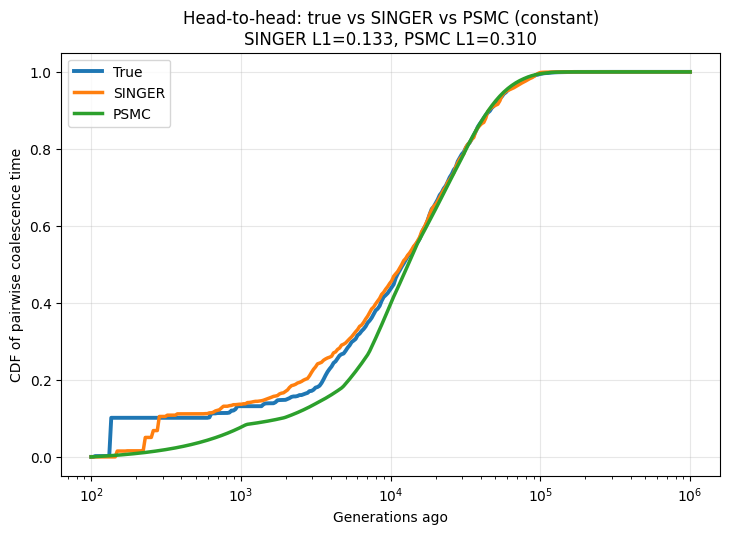

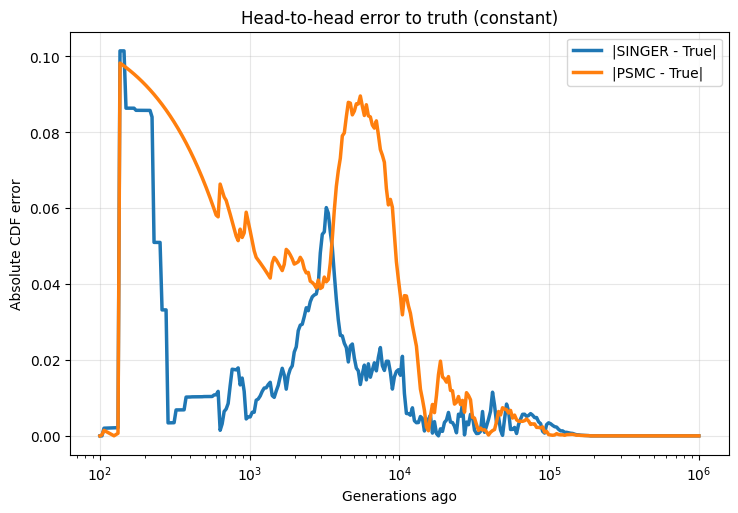

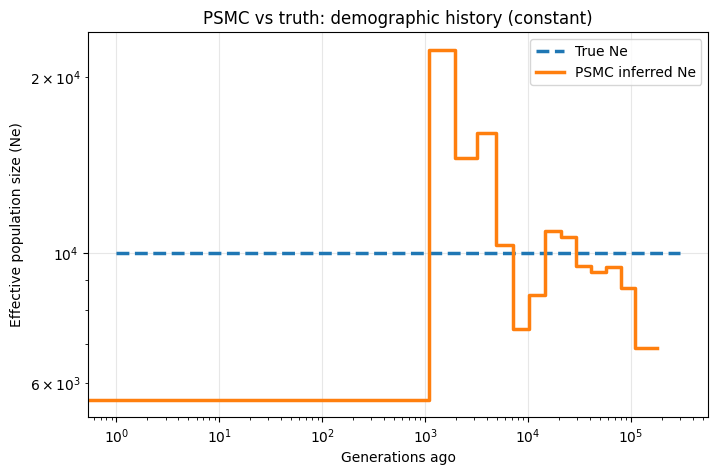

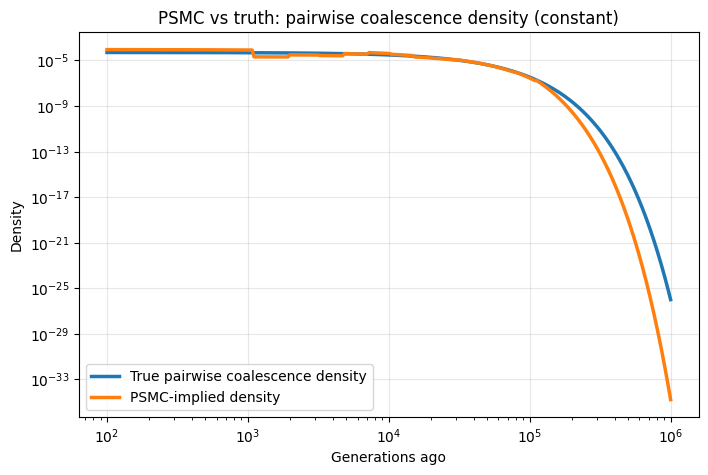

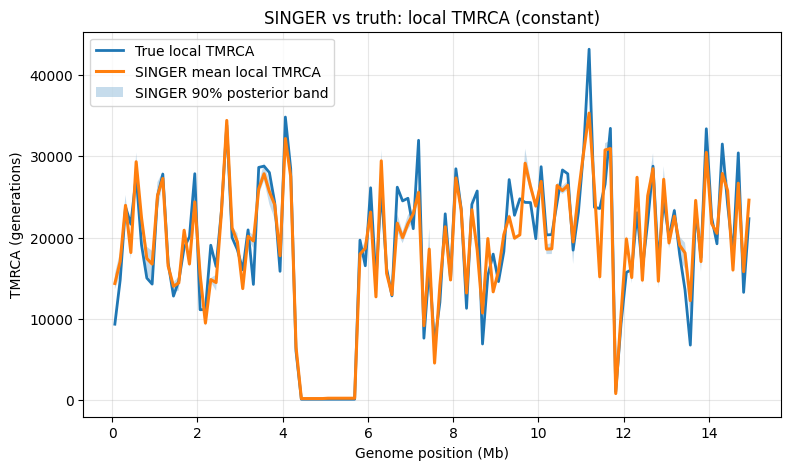

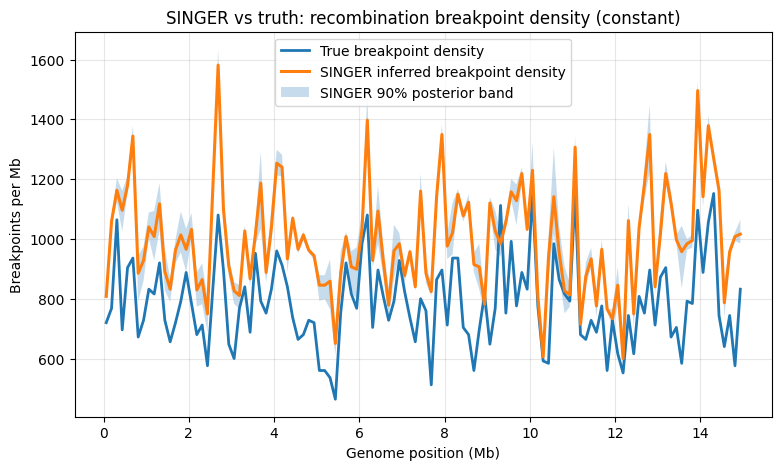

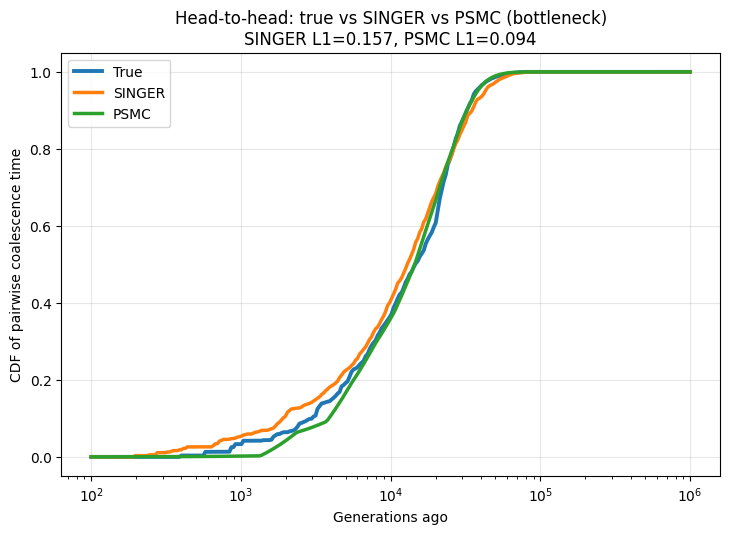

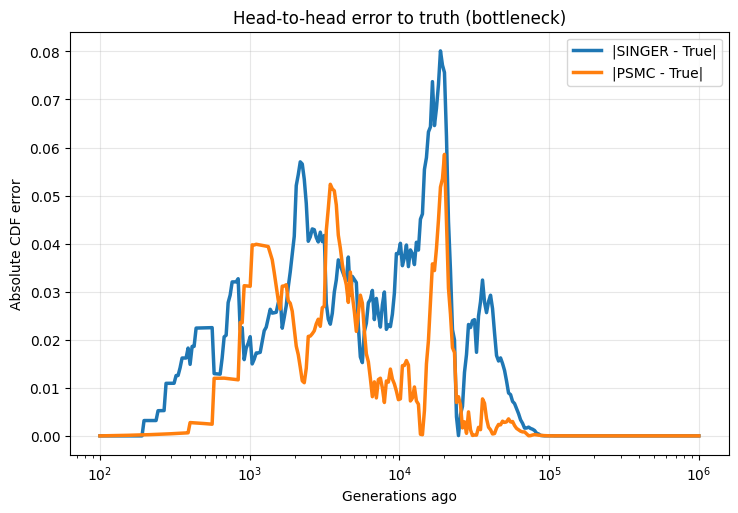

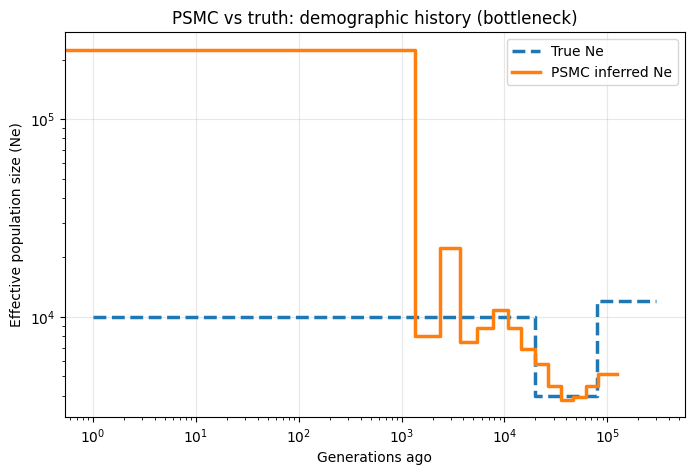

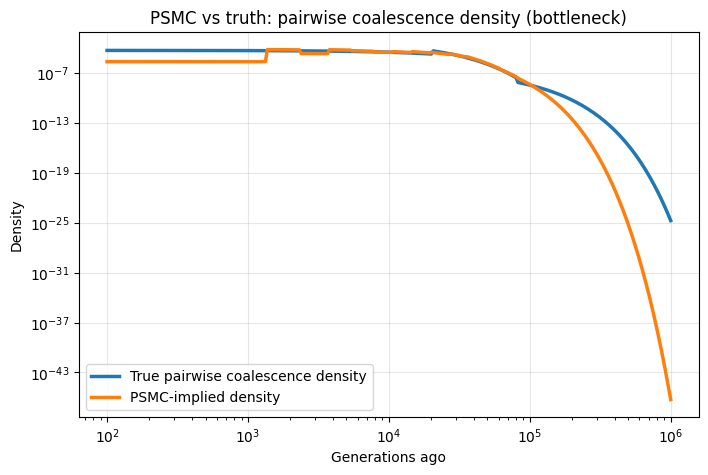

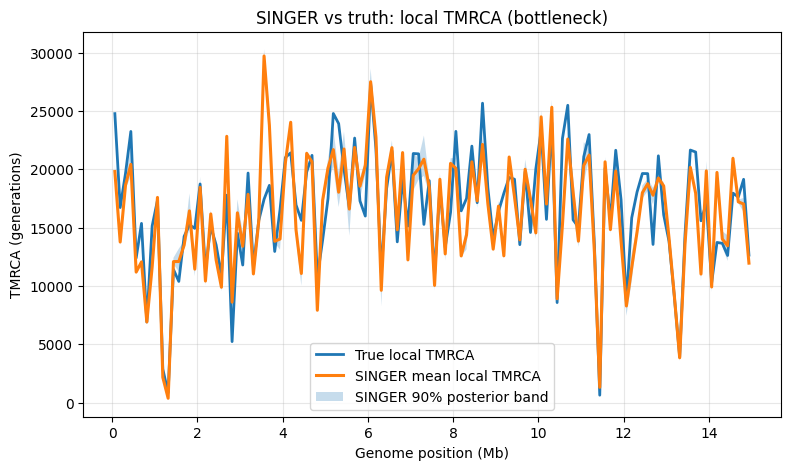

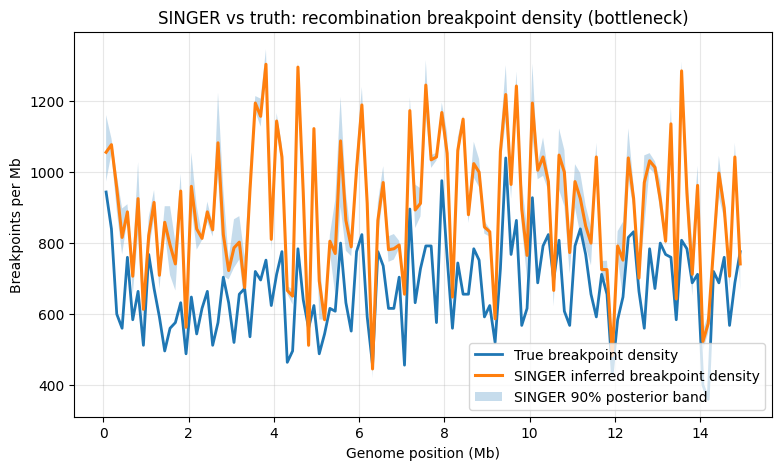

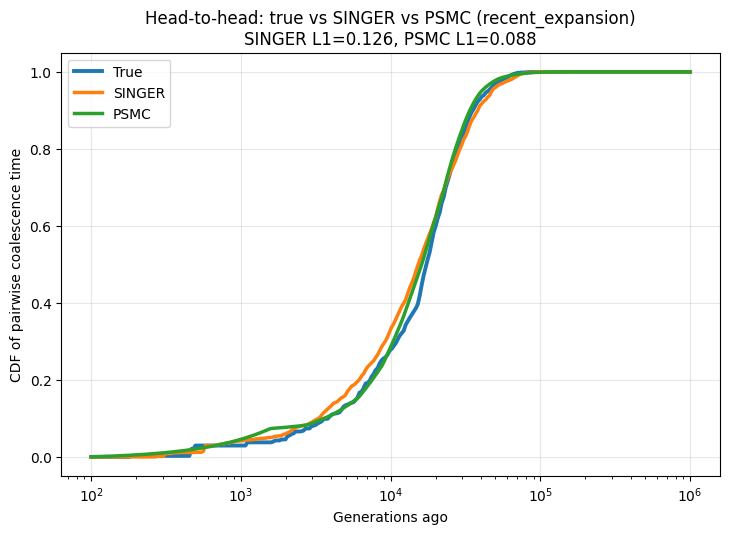

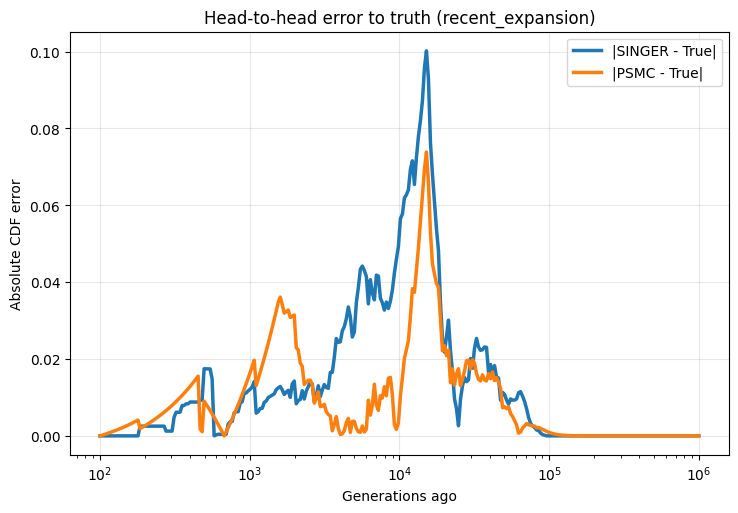

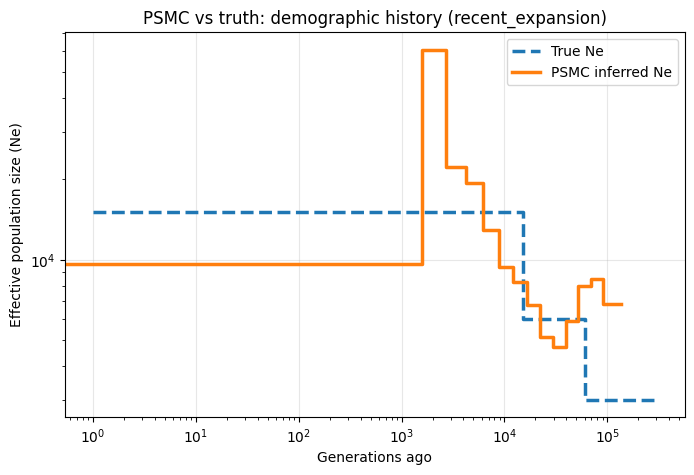

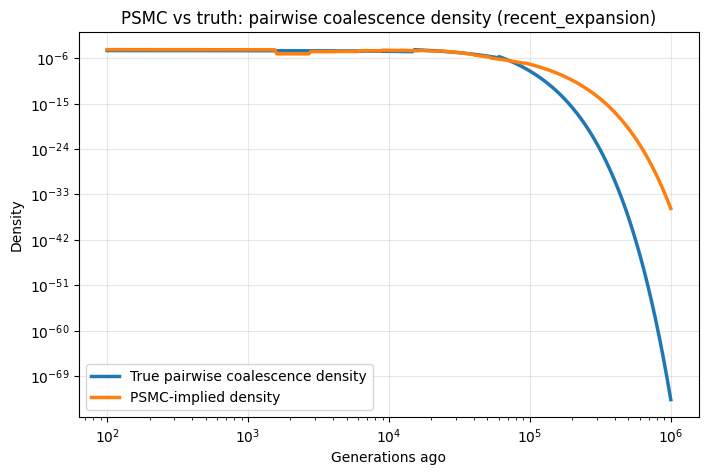

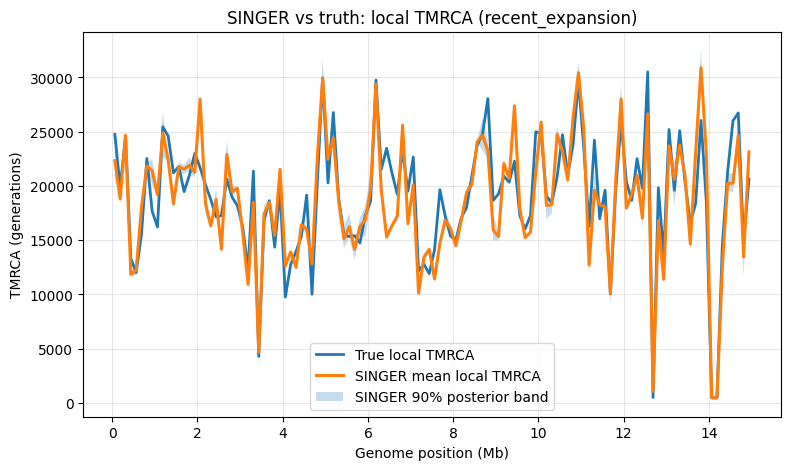

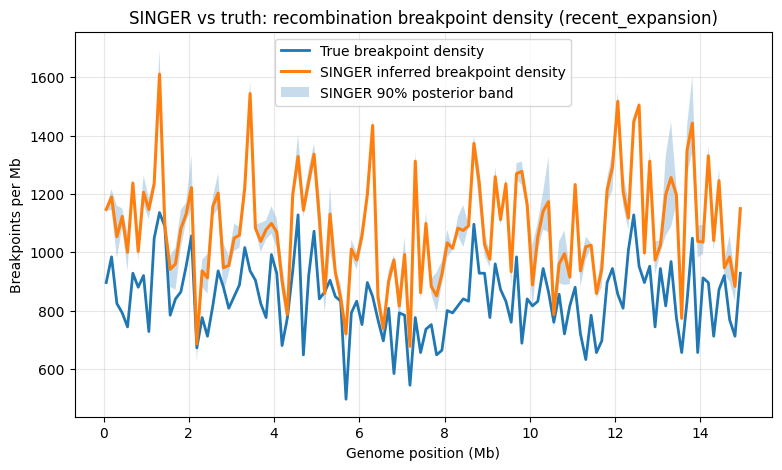

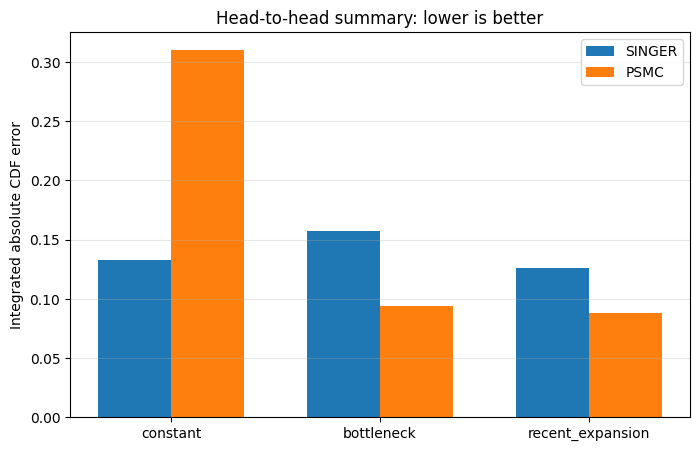

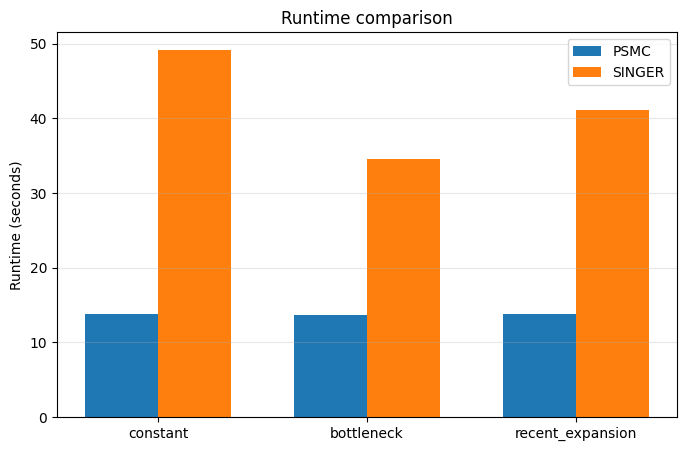

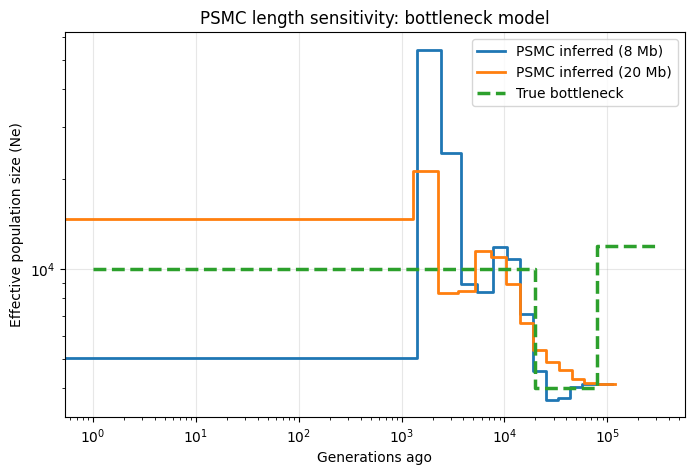

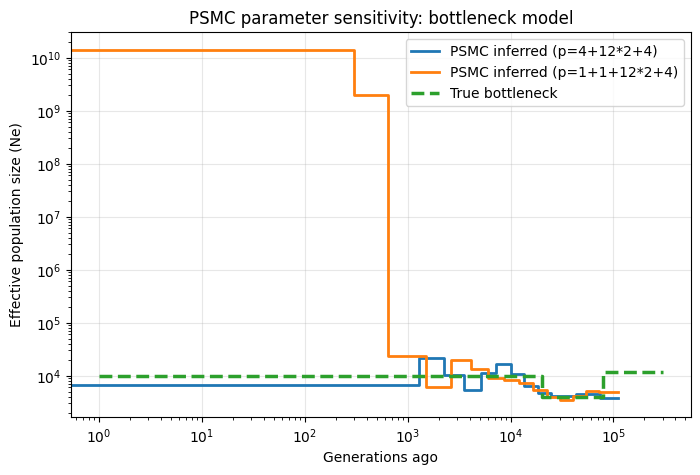

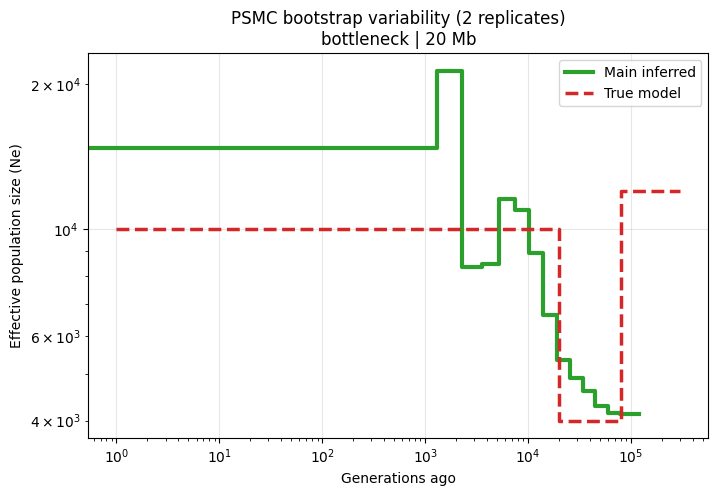

In [ ]:
# ===============================
# Cell 15: generate all visuals
# ===============================

if "main_results" in globals() and len(main_results) > 0:
    for r in main_results:
        plot_head_to_head_cdf(r)
        plot_head_to_head_error(r)
        plot_psmc_demography_accuracy(r)
        plot_psmc_coalescence_density(r)
        plot_singer_tmrca_accuracy(r)
        plot_singer_breakpoint_accuracy(r)

    plot_head_to_head_metric_bars(main_results)
    plot_runtime_comparison(main_results)
else:
    print("main_results not found. Please run Cell 10 first.")

if "length_results" in globals() and len(length_results) > 0:
    plot_length_sensitivity(length_results)
else:
    print("length_results not found. Please run Cell 11 first.")

if "pattern_results" in globals() and len(pattern_results) > 0:
    plot_pattern_sensitivity(pattern_results)
else:
    print("pattern_results not found. Please run Cell 12 first.")

if "base_boot_result" in globals() and "bootstrap_dfs" in globals() and len(bootstrap_dfs) > 0:
    plot_bootstrap_band(base_boot_result, bootstrap_dfs)
else:
    print("Bootstrap results not found. Please run Cell 13 first.")

In [ ]:
# ==================================
# Cell 16: combined summary table
# ==================================

all_summary_rows = []

for group_name, result_list in [
    ("main", main_results),
    ("length_test", length_results),
    ("pattern_test", pattern_results),
]:
    for r in result_list:
        all_summary_rows.append({
            "group": group_name,
            "model": r.get("model", np.nan),
            "seq_len_mb": r.get("seq_len_mb", np.nan),
            "p_pattern": r.get("p_pattern", np.nan),
            "n_diploids": r.get("n_diploids", np.nan),
            "fraction_K_bins": r.get("fraction_K_bins", np.nan),
            "theta0": r.get("theta0", np.nan),
            "N0": r.get("N0", np.nan),
            "RMSE_Ne": r.get("RMSE_Ne", np.nan),
            "RMSE_log10_Ne": r.get("RMSE_log10_Ne", np.nan),
            "MAPE_percent": r.get("MAPE_percent", np.nan),
            "PSMC_CDF_L1": r.get("PSMC_CDF_L1", np.nan),
            "SINGER_CDF_L1": r.get("SINGER_CDF_L1", np.nan),
            "PSMC_CDF_RMSE": r.get("PSMC_CDF_RMSE", np.nan),
            "SINGER_CDF_RMSE": r.get("SINGER_CDF_RMSE", np.nan),
            "simulation_seconds": r.get("simulation_seconds", np.nan),
            "psmc_seconds": r.get("psmc_seconds", np.nan),
            "singer_seconds": r.get("singer_seconds", np.nan),
        })

summary_all = pd.DataFrame(all_summary_rows)
summary_all = summary_all.sort_values(["group", "model", "seq_len_mb"]).reset_index(drop=True)
display(summary_all)

,group,model,seq_len_mb,p_pattern,n_diploids,fraction_K_bins,theta0,N0,RMSE_Ne,RMSE_log10_Ne,MAPE_percent,PSMC_CDF_L1,SINGER_CDF_L1,PSMC_CDF_RMSE,SINGER_CDF_RMSE,simulation_seconds,psmc_seconds,singer_seconds
0,length_test,bottleneck,8.0,4+12*2+4,1,0.039275,0.052106,10421.2,10926.748337,0.290932,54.158561,NaN,NaN,NaN,NaN,0.111618,8.366073,NaN
1,length_test,bottleneck,20.0,4+12*2+4,1,0.039615,0.045165,9033.0,4235.532718,0.228415,29.265336,NaN,NaN,NaN,NaN,0.497752,17.436096,NaN
2,main,bottleneck,15.0,4+12*2+4,4,0.040307,0.047666,9533.2,5086.736791,0.211500,35.031950,0.093647,0.157481,0.017460,0.024900,0.689458,13.678709,34.580710
3,main,constant,15.0,4+12*2+4,4,0.045413,0.029765,5953.0,2771.939179,0.110999,21.065310,0.309891,0.132585,0.047845,0.026312,1.696804,13.766082,49.087087
4,main,recent_expansion,15.0,4+12*2+4,4,0.045667,0.055476,11095.2,12618.422347,0.277830,76.647237,0.088383,0.126053,0.015962,0.023778,1.039199,13.832965,41.126868
5,pattern_test,bottleneck,15.0,4+12*2+4,1,0.037840,0.046300,9260.0,4883.117159,0.262836,33.609797,NaN,NaN,NaN,NaN,0.289133,13.815405,NaN
6,pattern_test,bottleneck,15.0,1+1+12*2+4,1,0.038747,0.050788,10157.6,4768.539414,0.221909,35.989248,NaN,NaN,NaN,NaN,0.318125,11.894776,NaN


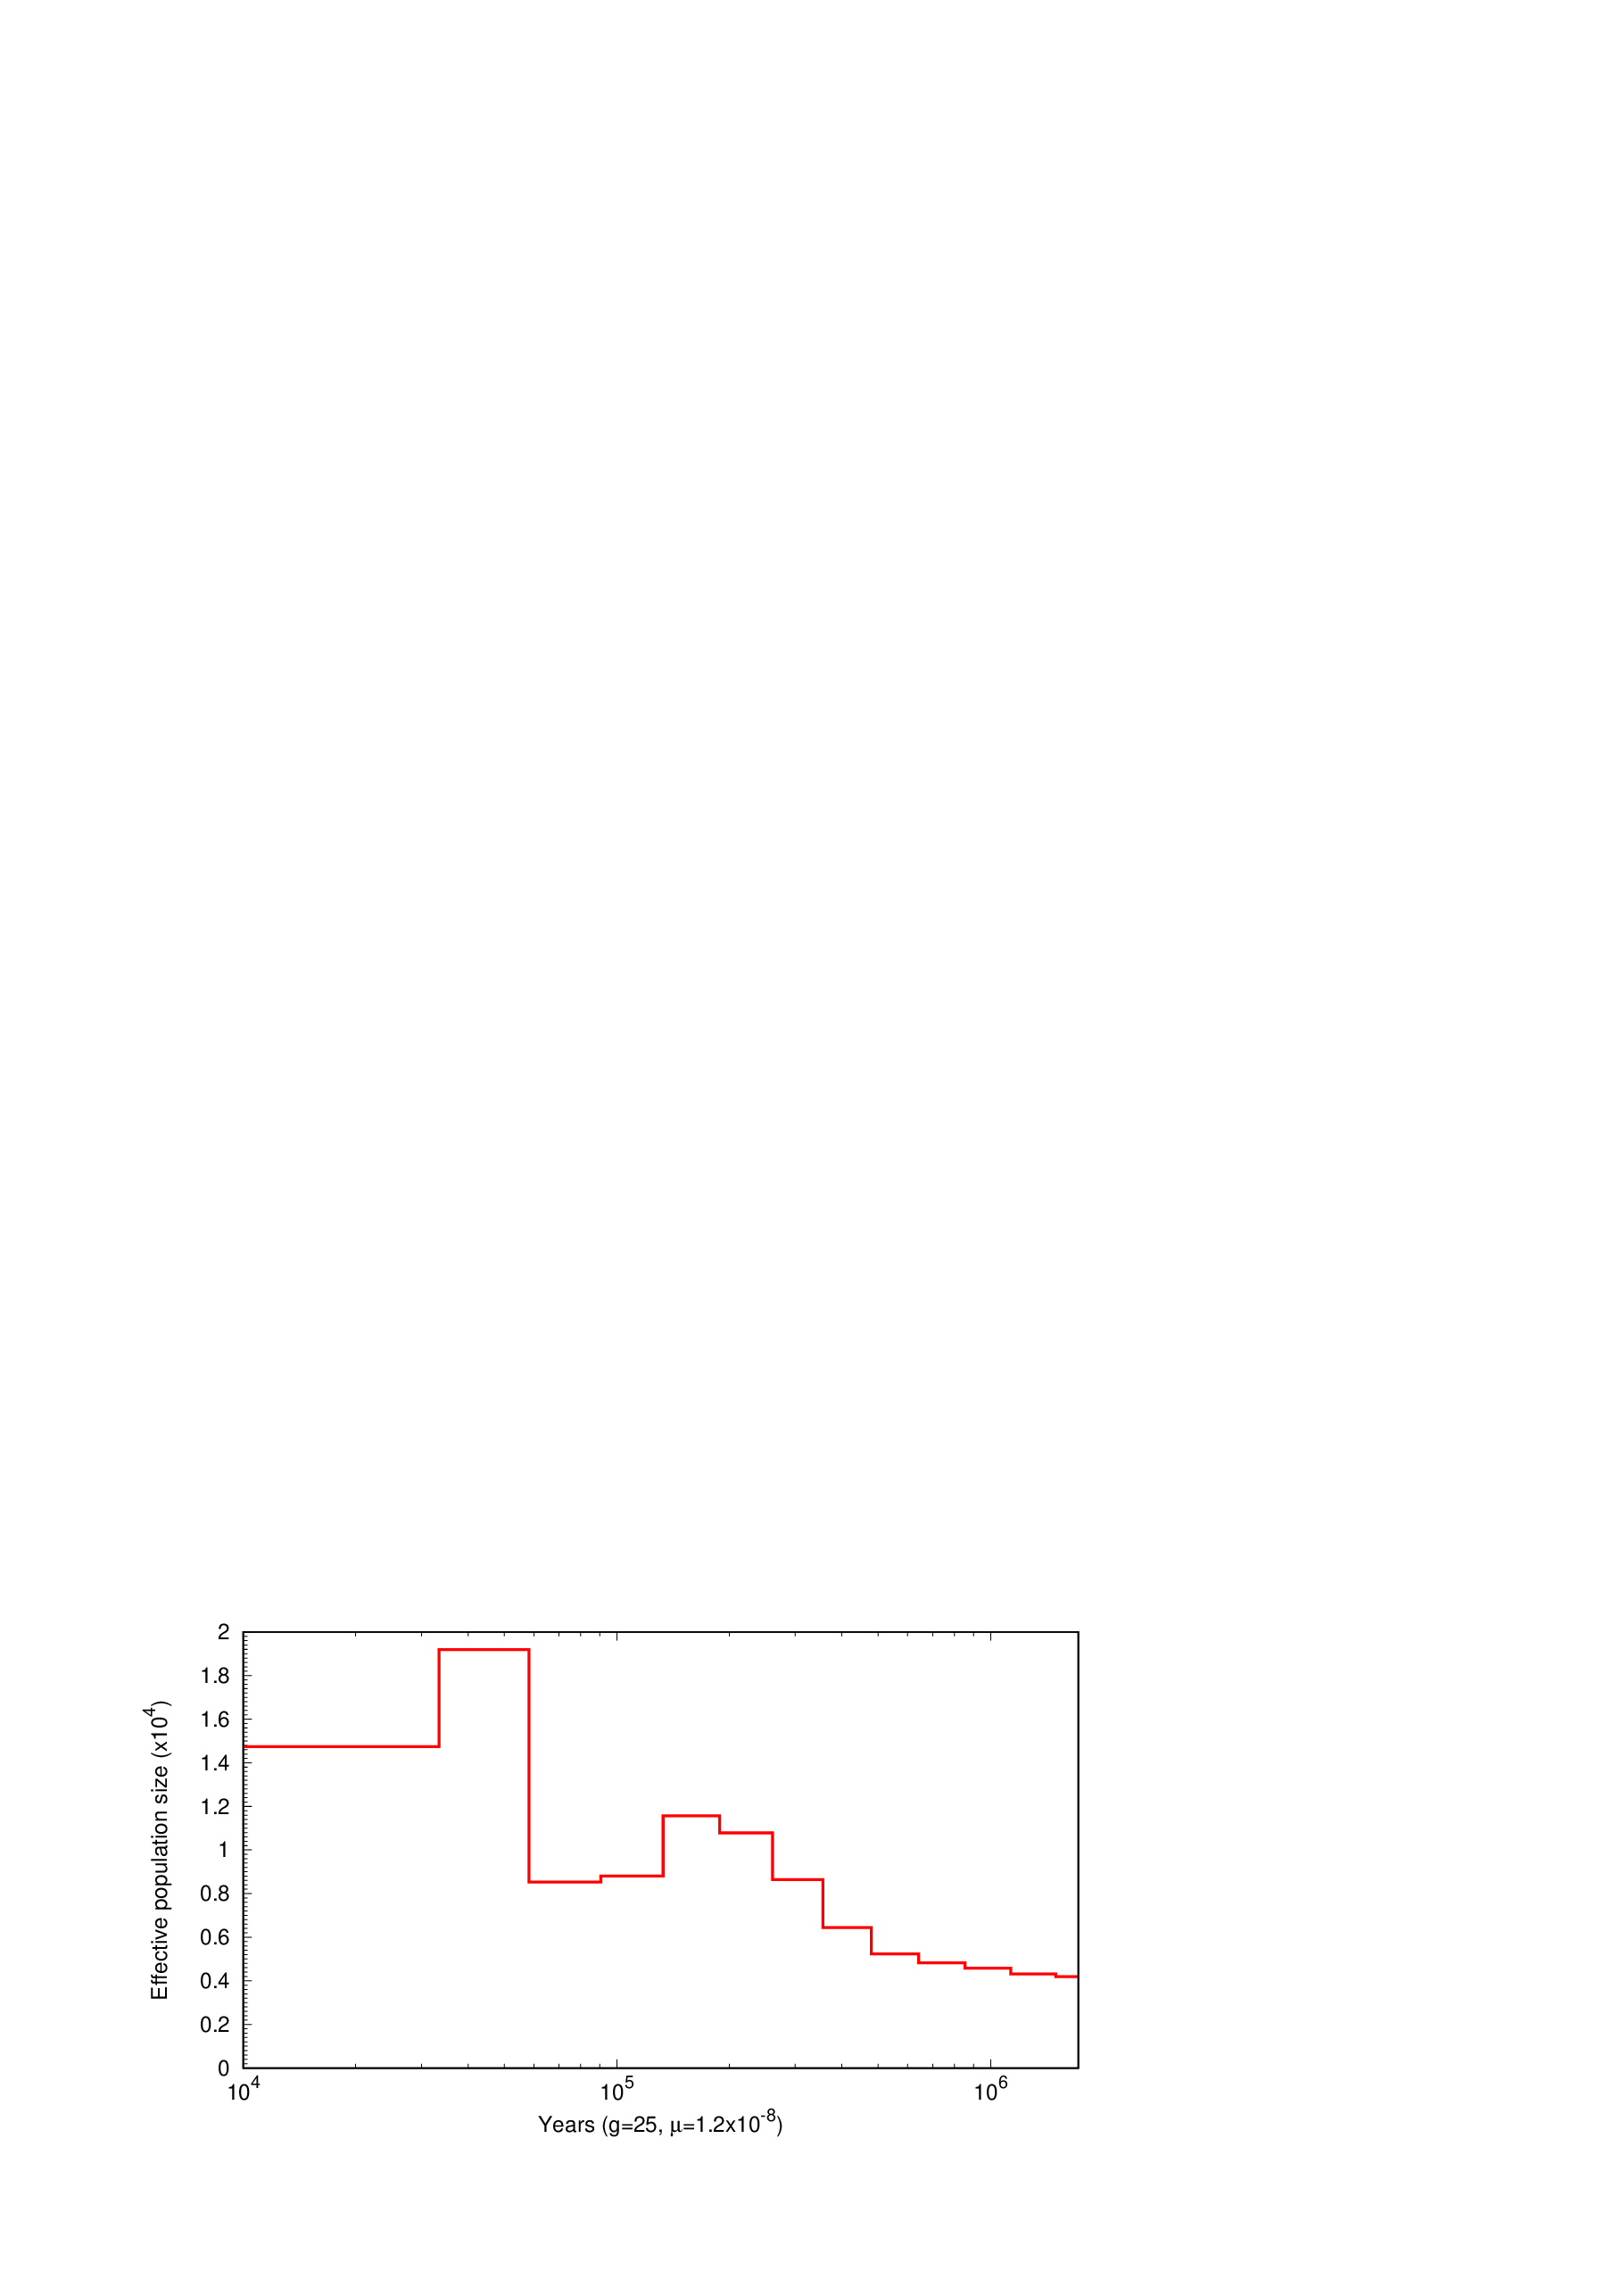

In [ ]:
# =========================================
# Cell 17: optional repo plot as inline PNG
# =========================================

from IPython.display import Image, display

def display_repo_plot_as_png(psmc_path, prefix_name):
    out_prefix = OUTDIR / prefix_name

    subprocess.run(
        [
            "perl",
            "/content/psmc/utils/psmc_plot.pl",
            "-u", str(MU),
            "-g", str(GENERATION_TIME),
            str(out_prefix),
            str(psmc_path),
        ],
        check=True,
    )

    subprocess.run([
        "gs",
        "-dSAFER",
        "-dBATCH",
        "-dNOPAUSE",
        "-sDEVICE=pngalpha",
        "-r220",
        f"-sOutputFile={out_prefix}.png",
        f"{out_prefix}.eps"
    ], check=True)

    display(Image(filename=f"{out_prefix}.png"))


# Example: show the clean long bottleneck run
display_repo_plot_as_png(base_boot_result["psmc_path"], "repo_plot_bottleneck_long")

In [ ]:
# ===========================================
# NEW CELL: ARG visualization (true vs SINGER)
# ===========================================

from IPython.display import HTML, display

def _sample_node_labels(ts):
    labels = {}
    for u in ts.samples():
        labels[u] = f"H{u}"
    return labels


def _get_singer_ts_for_global_position(result, position_bp, posterior_index=0):
    """
    Given a global genomic position, load the SINGER tree sequence
    for the corresponding 5Mb segment and return:
      - the loaded ts
      - the local position inside that segment
      - the segment index
    """
    seg_idx = int(position_bp // SINGER_WINDOW_SIZE)
    if seg_idx >= len(result["singer_segment_tree_files"]):
        raise ValueError(
            f"Position {position_bp} falls outside available SINGER segments."
        )

    seg_files = result["singer_segment_tree_files"][seg_idx]
    if posterior_index >= len(seg_files):
        raise ValueError(
            f"posterior_index={posterior_index} not available for segment {seg_idx}."
        )

    singer_ts = tskit.load(seg_files[posterior_index])
    local_pos = position_bp - seg_idx * SINGER_WINDOW_SIZE
    return singer_ts, local_pos, seg_idx


def draw_true_vs_singer_local_tree(result, position_bp=None, posterior_index=0):
    """
    Draw one local marginal tree from the true msprime ARG and one from SINGER
    at the same genomic position.
    """
    if result.get("ts_true", None) is None:
        raise ValueError("result['ts_true'] not found. Re-run Cell 9 after adding ts_true.")

    if position_bp is None:
        position_bp = int(result["seq_len_bp"] // 2)

    true_ts = result["ts_true"]
    singer_ts, local_pos, seg_idx = _get_singer_ts_for_global_position(
        result, position_bp, posterior_index=posterior_index
    )

    true_tree = true_ts.at(position_bp)
    singer_tree = singer_ts.at(local_pos)

    svg_true = true_tree.draw_svg(
        size=(520, 360),
        time_scale="rank",
        node_labels=_sample_node_labels(true_ts),
        y_axis=True,
        y_label="Tree height",
    )

    svg_singer = singer_tree.draw_svg(
        size=(520, 360),
        time_scale="rank",
        node_labels=_sample_node_labels(singer_ts),
        y_axis=True,
        y_label="Tree height",
    )

    html = f"""
    <div style="display:flex; gap:24px; align-items:flex-start; flex-wrap:wrap;">
        <div>
            <h3 style="margin-bottom:8px;">True ARG slice (msprime)</h3>
            <div style="margin-bottom:8px;">
                Position: {position_bp:,} bp
            </div>
            {svg_true}
        </div>
        <div>
            <h3 style="margin-bottom:8px;">SINGER reconstructed ARG slice</h3>
            <div style="margin-bottom:8px;">
                Position: {position_bp:,} bp
                <br>
                Segment: {seg_idx}
                <br>
                Posterior sample: {posterior_index}
            </div>
            {svg_singer}
        </div>
    </div>
    """
    display(HTML(html))

In [ ]:
# ===========================================
# NEW CELL: small-region tree-sequence overview
# ===========================================

def draw_true_vs_singer_tree_sequence_region(
    result,
    start_bp=0,
    width_bp=1_000_000,
    posterior_index=0,
    max_num_trees=12
):
    """
    Draw a small genomic region as a tree-sequence panel for:
      - true msprime ARG
      - SINGER reconstructed ARG
    """
    if result.get("ts_true", None) is None:
        raise ValueError("result['ts_true'] not found. Re-run Cell 9 after adding ts_true.")

    end_bp = min(int(result["seq_len_bp"]), int(start_bp + width_bp))
    center_bp = 0.5 * (start_bp + end_bp)

    true_ts = result["ts_true"]
    singer_ts, local_center, seg_idx = _get_singer_ts_for_global_position(
        result, center_bp, posterior_index=posterior_index
    )

    seg_start = seg_idx * SINGER_WINDOW_SIZE
    local_start = max(0, start_bp - seg_start)
    local_end = min(singer_ts.sequence_length, end_bp - seg_start)

    true_sub = true_ts.keep_intervals([[start_bp, end_bp]], simplify=False).trim()
    singer_sub = singer_ts.keep_intervals([[local_start, local_end]], simplify=False).trim()

    svg_true = true_sub.draw_svg(
        size=(820, 280),
        x_scale="physical",
        time_scale="rank",
        max_num_trees=max_num_trees,
        node_labels={},
        y_axis=True,
        y_label="Tree height",
    )

    svg_singer = singer_sub.draw_svg(
        size=(820, 280),
        x_scale="physical",
        time_scale="rank",
        max_num_trees=max_num_trees,
        node_labels={},
        y_axis=True,
        y_label="Tree height",
    )

    html = f"""
    <div style="display:flex; flex-direction:column; gap:16px;">
        <div>
            <h3 style="margin-bottom:8px;">True msprime tree sequence</h3>
            <div style="margin-bottom:8px;">
                Region: {start_bp:,} - {end_bp:,} bp
            </div>
            {svg_true}
        </div>
        <div>
            <h3 style="margin-bottom:8px;">SINGER reconstructed tree sequence</h3>
            <div style="margin-bottom:8px;">
                Same region, posterior sample {posterior_index}, segment {seg_idx}
            </div>
            {svg_singer}
        </div>
    </div>
    """
    display(HTML(html))

In [ ]:
# ===========================================
# NEW CELL: ARG comparison panel
# ===========================================

def plot_arg_comparison_panel(result, center_bp=None, half_window_bp=1_000_000):
    """
    One presentation-friendly panel around a chosen genomic location.
    """
    if result["singer_tmrca_curve"] is None or result["singer_breakpoint_curve"] is None:
        print("No SINGER result found for this experiment.")
        return

    if center_bp is None:
        center_bp = result["seq_len_bp"] // 2

    left = max(0, center_bp - half_window_bp)
    right = min(result["seq_len_bp"], center_bp + half_window_bp)

    true_tmrca = result["true_tmrca_curve"]
    singer_tmrca = result["singer_tmrca_curve"]

    true_bp = result["true_breakpoint_curve"]
    singer_bp = result["singer_breakpoint_curve"]

    mask_true_tmrca = (true_tmrca["position"] >= left) & (true_tmrca["position"] <= right)
    mask_singer_tmrca = (singer_tmrca["position"] >= left) & (singer_tmrca["position"] <= right)

    mask_true_bp = (true_bp["position"] >= left) & (true_bp["position"] <= right)
    mask_singer_bp = (singer_bp["position"] >= left) & (singer_bp["position"] <= right)

    plt.figure(figsize=(10, 4.5))
    plt.plot(
        true_tmrca.loc[mask_true_tmrca, "position"] / 1e6,
        true_tmrca.loc[mask_true_tmrca, "tmrca"],
        linewidth=2.2,
        label="True local TMRCA",
    )
    plt.plot(
        singer_tmrca.loc[mask_singer_tmrca, "position"] / 1e6,
        singer_tmrca.loc[mask_singer_tmrca, "mean_tmrca"],
        linewidth=2.2,
        label="SINGER local TMRCA",
    )
    plt.fill_between(
        singer_tmrca.loc[mask_singer_tmrca, "position"] / 1e6,
        singer_tmrca.loc[mask_singer_tmrca, "ci_low"],
        singer_tmrca.loc[mask_singer_tmrca, "ci_high"],
        alpha=0.25,
        label="SINGER 90% band",
    )
    plt.axvline(center_bp / 1e6, linestyle="--", linewidth=1.5)
    plt.xlabel("Genome position (Mb)")
    plt.ylabel("TMRCA (generations)")
    plt.title(f"ARG panel: local TMRCA around {center_bp:,} bp")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4.5))
    plt.plot(
        true_bp.loc[mask_true_bp, "position"] / 1e6,
        true_bp.loc[mask_true_bp, "breakpoint_density_per_mb"],
        linewidth=2.2,
        label="True breakpoint density",
    )
    plt.plot(
        singer_bp.loc[mask_singer_bp, "position"] / 1e6,
        singer_bp.loc[mask_singer_bp, "mean_density"],
        linewidth=2.2,
        label="SINGER breakpoint density",
    )
    plt.fill_between(
        singer_bp.loc[mask_singer_bp, "position"] / 1e6,
        singer_bp.loc[mask_singer_bp, "ci_low"],
        singer_bp.loc[mask_singer_bp, "ci_high"],
        alpha=0.25,
        label="SINGER 90% band",
    )
    plt.axvline(center_bp / 1e6, linestyle="--", linewidth=1.5)
    plt.xlabel("Genome position (Mb)")
    plt.ylabel("Breakpoints per Mb")
    plt.title(f"ARG panel: recombination structure around {center_bp:,} bp")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

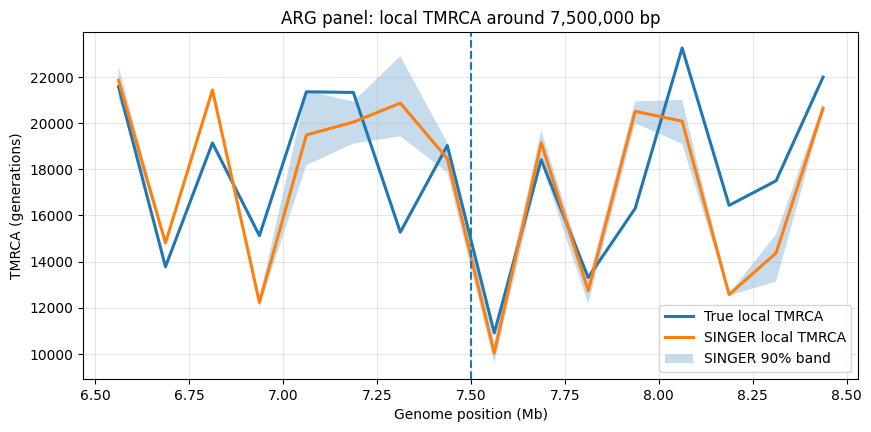

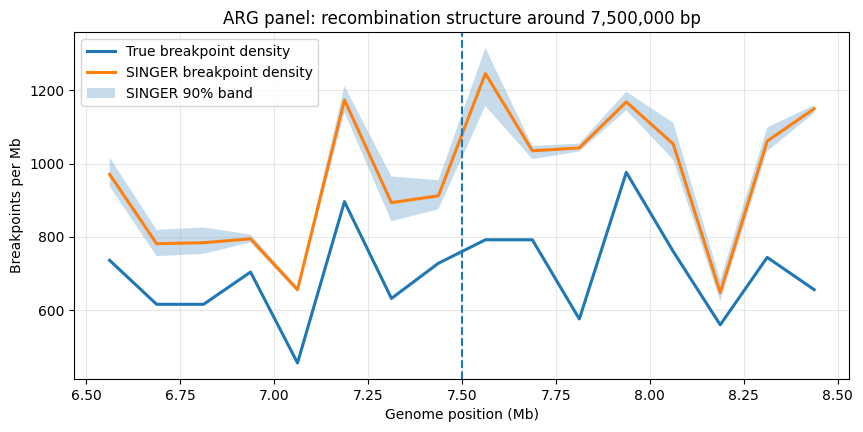

In [ ]:
# one local tree comparison
draw_true_vs_singer_local_tree(main_results[1], position_bp=7_500_000, posterior_index=0)

# one small-region tree-sequence comparison
draw_true_vs_singer_tree_sequence_region(
    main_results[1],
    start_bp=7_000_000,
    width_bp=1_000_000,
    posterior_index=0,
)

# one panel around the same region
plot_arg_comparison_panel(main_results[1], center_bp=7_500_000, half_window_bp=1_000_000)